# Public Transport Delay Prediction using Machine Learning

## Business Problem

Public transportation systems are critical for urban mobility. Delays caused by weather conditions, traffic congestion, holidays, public events, and operational issues reduce passenger satisfaction and increase operational costs.

The objective of this project is to develop a machine learning model capable of predicting whether a public transport trip will be delayed based on scheduling information, weather conditions, traffic levels, and city events.

Such predictions can help transport authorities:

- Improve operational planning
- Optimize route scheduling
- Inform passengers proactively
- Reduce congestion
- Improve service reliability

---

## Project Objectives

This project aims to:

- Understand the dataset through Exploratory Data Analysis (EDA)
- Identify important factors contributing to transport delays
- Engineer meaningful features
- Build multiple Machine Learning models
- Compare model performance
- Explain predictions using Explainable AI (SHAP)

---

## Dataset Overview

The dataset contains information related to

- Transport schedules
- Weather
- Traffic conditions
- Public events
- Holidays
- Peak hours
- Delay information

Target Variable

**Delayed**

- 0 → On Time
- 1 → Delayed

Dataset Link: https://www.kaggle.com/datasets/khushikyad001/public-transport-delays-with-weather-and-events/data

In [84]:
#import libraries 

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

In [85]:
#load dataset

df = pd.read_csv("../data/public_transport_delays.csv")
df.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NaN,500,46,0,0,6,Spring,1


In [86]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 2000
Number of Columns : 24


In [87]:
df.columns

Index(['trip_id', 'date', 'time', 'transport_type', 'route_id',
       'origin_station', 'destination_station', 'scheduled_departure',
       'scheduled_arrival', 'actual_departure_delay_min',
       'actual_arrival_delay_min', 'weather_condition', 'temperature_C',
       'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_type',
       'event_attendance_est', 'traffic_congestion_index', 'holiday',
       'peak_hour', 'weekday', 'season', 'delayed'],
      dtype='object')

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   object 
 1   date                        2000 non-null   object 
 2   time                        2000 non-null   object 
 3   transport_type              2000 non-null   object 
 4   route_id                    2000 non-null   object 
 5   origin_station              2000 non-null   object 
 6   destination_station         2000 non-null   object 
 7   scheduled_departure         2000 non-null   object 
 8   scheduled_arrival           2000 non-null   object 
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   object 
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 

In [89]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
actual_departure_delay_min,2000.0,8.68800,6.268118,-2.0,3.0,9.0,14.0,19.0
actual_arrival_delay_min,2000.0,13.31800,9.289727,-3.0,5.0,13.0,21.0,29.0
temperature_C,2000.0,15.12135,11.479424,-5.0,5.1,15.3,24.8,35.0
humidity_percent,2000.0,64.71400,20.334747,30.0,46.0,65.0,83.0,99.0
wind_speed_kmh,2000.0,29.30050,17.264015,0.0,15.0,29.0,45.0,59.0
precipitation_mm,2000.0,9.86070,5.781373,0.0,4.9,9.7,14.8,20.0
event_attendance_est,2000.0,6420.25000,15198.306129,0.0,0.0,0.0,2000.0,50000.0
traffic_congestion_index,2000.0,50.24400,29.225751,0.0,25.0,50.0,76.0,99.0
holiday,2000.0,0.08950,0.285535,0.0,0.0,0.0,0.0,1.0
peak_hour,2000.0,0.27200,0.445101,0.0,0.0,0.0,1.0,1.0


In [90]:
df.describe(include="object").T

,count,unique,top,freq
trip_id,2000,2000,T00000,1
date,2000,22,2023-01-12,96
time,2000,96,05:00:00,21
transport_type,2000,4,Bus,525
route_id,2000,20,Route_3,114
origin_station,2000,50,Station_17,55
destination_station,2000,50,Station_26,56
scheduled_departure,2000,474,11:46:00,11
scheduled_arrival,2000,1068,12:43:00,7
weather_condition,2000,6,Clear,343


The dataset contains information about public transport trips, including schedule, delays, weather, traffic, and special events.

# Categorical Columns
trip_id : Unique ID for each trip 
>
transport_type : Type of transport (bus, train, etc.)
>
route_id : Route identifier
>
origin_station : Starting station
>
destination_station : Ending station
>
weather_condition : Weather description
>
event_type : Type of event (if any)
holiday : Whether the day is a public holiday
>
peak_hour : Whether the trip occurs during peak hours
>
weekday : Day of the week
>
season : Season
>
delayed : Whether the trip was delayed (0 = No, 1 = Yes)
>
# Numeric Columns
temperature_C : Temperature in Celsius
>
humidity_percent : Humidity (%)
>
wind_speed_kmh : Wind speed (km/h)
>
precipitation_mm : Precipitation (mm)
>
event_attendance_est : Estimated number of people attending the event
>
traffic_congestion_index : Traffic congestion level
>
actual_departure_delay_min : Departure delay in minutes
>
actual_arrival_delay_min : Arrival delay in minutes
>
# Datetime Columns
>
date : Date of the trip
>
time : Time of the trip
>
scheduled_departure : Scheduled departure time
>
scheduled_arrival : Scheduled arrival time

In [91]:
#Data Quality Report

report = pd.DataFrame({

"Data Type":df.dtypes,

"Missing Values":df.isnull().sum(),

"Missing %":round(df.isnull().sum()/len(df)*100,2),

"Unique Values":df.nunique(),

"Duplicate":df.duplicated().sum()

})

report

,Data Type,Missing Values,Missing %,Unique Values,Duplicate
trip_id,object,0,0.00,2000,0
date,object,0,0.00,22,0
time,object,0,0.00,96,0
transport_type,object,0,0.00,4,0
route_id,object,0,0.00,20,0
origin_station,object,0,0.00,50,0
destination_station,object,0,0.00,50,0
scheduled_departure,object,0,0.00,474,0
scheduled_arrival,object,0,0.00,1068,0
actual_departure_delay_min,int64,0,0.00,22,0


In [92]:
#Memory usage

memory = df.memory_usage(deep=True)

memory

Index                            128
trip_id                       126000
date                          134000
time                          130000
transport_type                122459
route_id                      129091
origin_station                133663
destination_station           133661
scheduled_departure           130000
scheduled_arrival             130000
actual_departure_delay_min     16000
actual_arrival_delay_min       16000
weather_condition             122999
temperature_C                  16000
humidity_percent               16000
wind_speed_kmh                 16000
precipitation_mm               16000
event_type                     90368
event_attendance_est           16000
traffic_congestion_index       16000
holiday                        16000
peak_hour                      16000
weekday                        16000
season                        126000
delayed                        16000
dtype: int64

In [93]:
#Total memory

print(f"Memory Usage : {memory.sum()/1024**2:.2f} MB")

Memory Usage : 1.62 MB


In [94]:
#Missing value analysis

missing = pd.DataFrame({

"Missing":df.isnull().sum(),

"Percentage":round(df.isnull().sum()/len(df)*100,2)

})

missing = missing.sort_values("Percentage",ascending=False)

missing

,Missing,Percentage
event_type,1173,58.65
trip_id,0,0.00
date,0,0.00
season,0,0.00
weekday,0,0.00
peak_hour,0,0.00
holiday,0,0.00
traffic_congestion_index,0,0.00
event_attendance_est,0,0.00
precipitation_mm,0,0.00


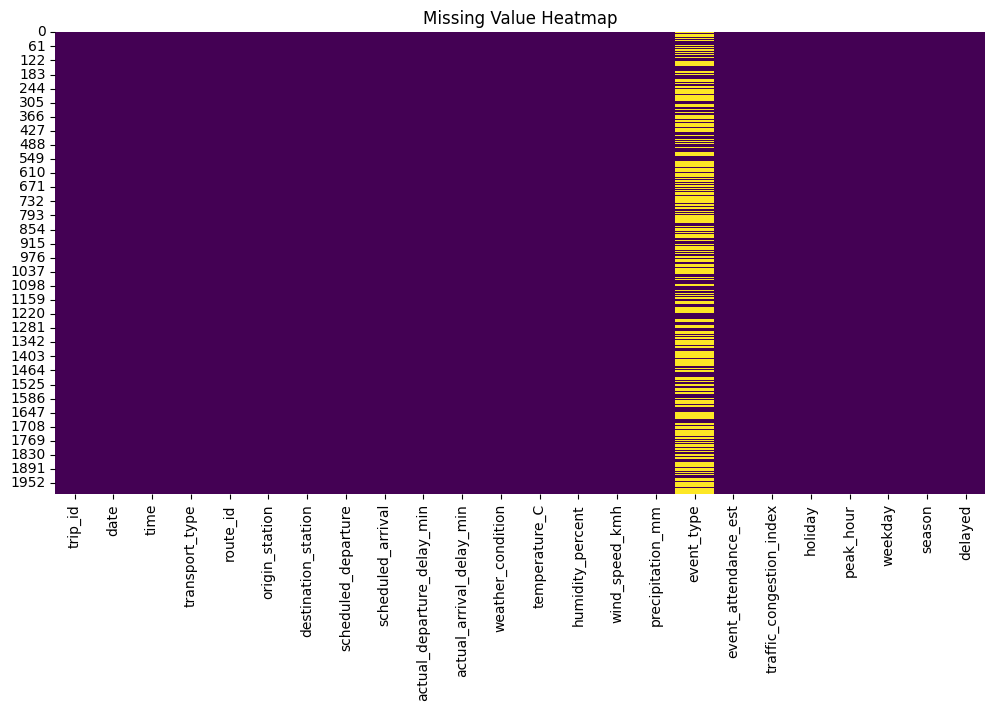

In [95]:
plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(),
            cmap="viridis",
            cbar=False)

plt.title("Missing Value Heatmap")

plt.show()

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


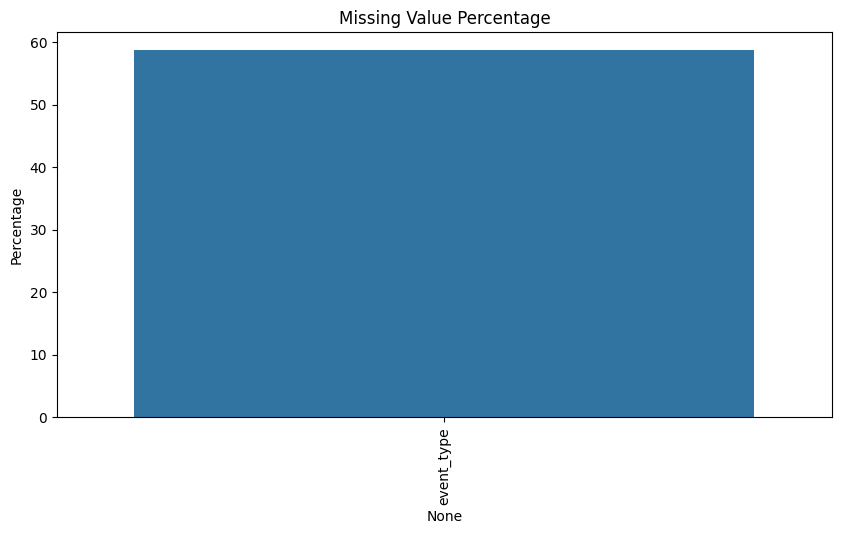

In [96]:
#barplot

missing = missing[missing["Missing"]>0]

plt.figure(figsize=(10,5))

sns.barplot(
    x=missing.index,
    y=missing["Percentage"]
)

plt.xticks(rotation=90)

plt.title("Missing Value Percentage")

plt.show()

In [97]:
# Duplicate Analysis

duplicates = df.duplicated().sum()

print("Duplicate Rows :",duplicates)

Duplicate Rows : 0


In [98]:
#Unique Values

for col in df.columns:

    print("="*40)

    print(col)

    print(df[col].nunique())

trip_id
2000
date
22
time
96
transport_type
4
route_id
20
origin_station
50
destination_station
50
scheduled_departure
474
scheduled_arrival
1068
actual_departure_delay_min
22
actual_arrival_delay_min
33
weather_condition
6
temperature_C
397
humidity_percent
70
wind_speed_kmh
60
precipitation_mm
201
event_type
5
event_attendance_est
5
traffic_congestion_index
100
holiday
2
peak_hour
2
weekday
7
season
4
delayed
2


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distribution, patterns,
relationships, and potential anomalies present in the dataset.

The analysis focuses on:

- Univariate analysis of individual variables
- Numerical variable distributions
- Categorical variable distributions
- Target variable distribution
- Relationships between features and transport delays
- Correlation between numerical variables
- Identification of patterns related to weather, traffic, events and scheduling

In [99]:
# Target variable distribution

print("Target Variable: delayed")
print("\nValue Counts:")
print(df['delayed'].value_counts())

print("\nPercentage Distribution:")
print(df['delayed'].value_counts(normalize=True) * 100)

Target Variable: delayed

Value Counts:
delayed
1    1499
0     501
Name: count, dtype: int64

Percentage Distribution:
delayed
1    74.95
0    25.05
Name: proportion, dtype: float64


C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


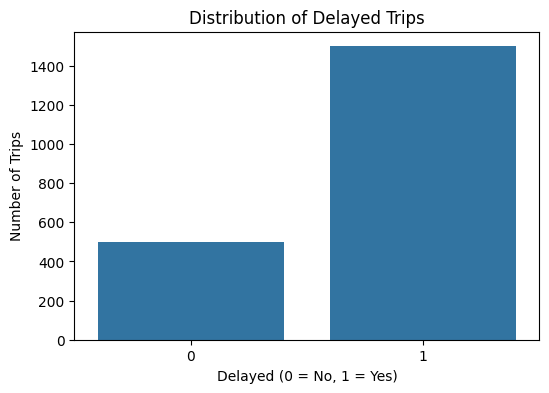

In [100]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='delayed')

plt.title('Distribution of Delayed Trips')
plt.xlabel('Delayed (0 = No, 1 = Yes)')
plt.ylabel('Number of Trips')

plt.show()

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


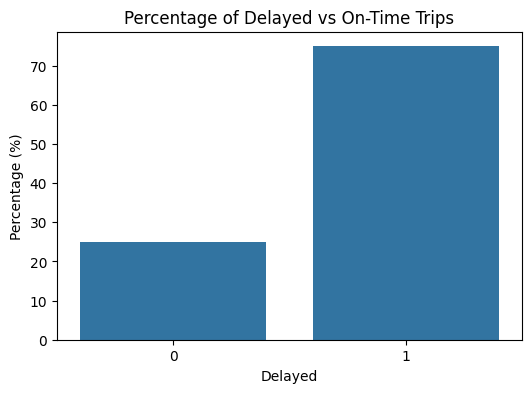

In [101]:
target_percentage = (
    df['delayed']
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

target_percentage.columns = ['Delayed', 'Percentage']

plt.figure(figsize=(6, 4))

sns.barplot(
    data=target_percentage,
    x='Delayed',
    y='Percentage'
)

plt.title('Percentage of Delayed vs On-Time Trips')
plt.ylabel('Percentage (%)')
plt.xlabel('Delayed')

plt.show()

### Target Variable Analysis

The target variable `delayed` is imbalanced.

- 1,499 trips (74.95%) were delayed.
- 501 trips (25.05%) were not delayed.

Therefore, delayed trips represent the majority class, while on-time trips represent the minority class.

A baseline model that predicts every trip as delayed would already achieve approximately 74.95% accuracy. Consequently, accuracy alone would not be a sufficient metric for evaluating the classification models.

To address this issue, model evaluation will focus on Precision, Recall, F1-score, ROC-AUC and the Confusion Matrix. Class imbalance techniques such as class weighting and SMOTE will also be investigated during the preprocessing and modelling stages.

In [102]:
# Missing event_type representation

# Missing = no event -> missing values have meaningful information 
# Missing = information not recorded -> treating as 'no event' is incorrect 

df['event_type'].value_counts(dropna=False)

event_type
NaN         1173
Festival     221
Sports       212
Concert      203
Parade       105
Protest       86
Name: count, dtype: int64

In [103]:
df[
    ['event_type', 'event_attendance_est']
].isnull().sum()

event_type              1173
event_attendance_est       0
dtype: int64

In [104]:
df[
    df['event_type'].isnull()
][
    ['event_type', 'event_attendance_est']
].head(20)

,event_type,event_attendance_est
0,NaN,500
1,NaN,0
3,NaN,500
4,NaN,500
7,NaN,0
9,NaN,50000
10,NaN,0
11,NaN,2000
13,NaN,10000
14,NaN,500


There are many missing event_type records where event attendance is clearly greater than 0.

So a missing event_type cannot reliably mean "No Event."

If we replaced every NaN with "No Event", we'd incorrectly classify records with event attendance of 50,000 as having no event.

In [105]:
pd.crosstab(
    df['event_type'].isnull(),
    df['event_attendance_est'] > 0,
    margins=True
)

event_attendance_est,False,True,All
event_type,,,
False,503,324,827
True,713,460,1173
All,1216,784,2000


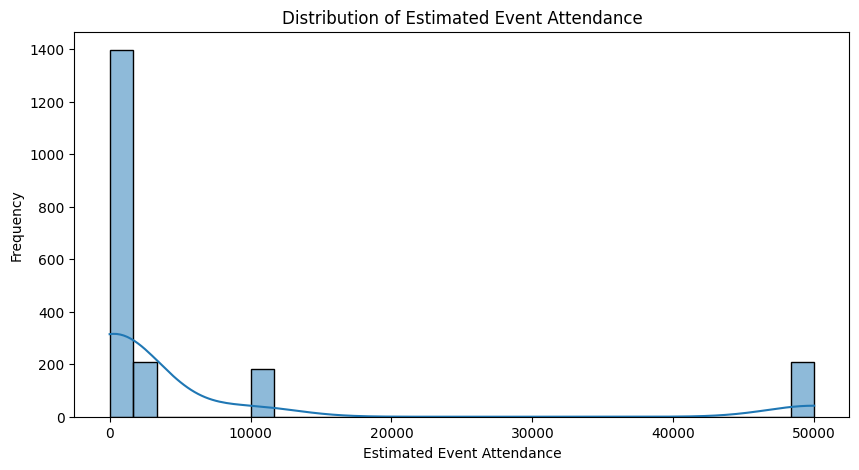

In [106]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='event_attendance_est',
    bins=30,
    kde=True
)

plt.title('Distribution of Estimated Event Attendance')

plt.xlabel('Estimated Event Attendance')

plt.ylabel('Frequency')

plt.show()

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


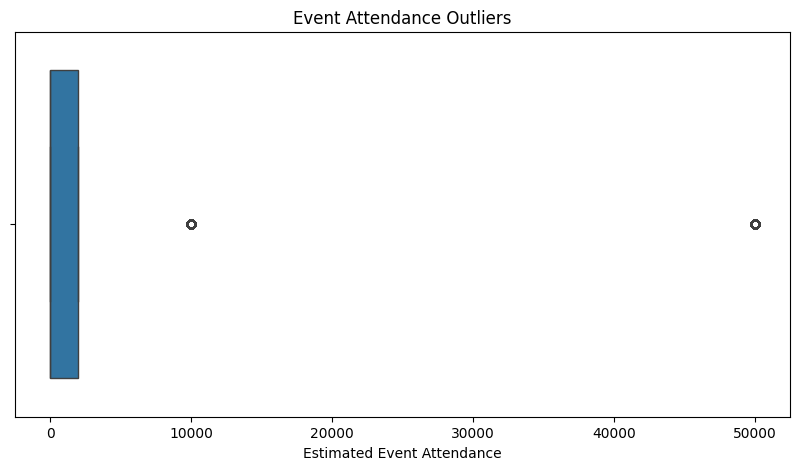

In [107]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='event_attendance_est'
)

plt.title('Event Attendance Outliers')

plt.xlabel('Estimated Event Attendance')

plt.show()

### Event Type Missing Value Analysis

The `event_type` variable contains 1,173 missing observations out of 2,000
records. Further investigation was conducted using `event_attendance_est`
to determine whether these missing values represent trips without events.

The analysis found that 460 of the 1,173 records with missing `event_type`
have positive estimated event attendance. Therefore, missing `event_type`
cannot be interpreted as the absence of an event.

The missing values are consequently treated as an `Unknown` event type rather
than `No Event`.

A separate binary feature, `has_event`, will be created from
`event_attendance_est`, where trips with attendance greater than zero are
considered to have an event.

This approach preserves the information contained in both variables without
making an unsupported assumption about the meaning of the missing values.

# Numerical Columns

For this dataset, the numerical columns include:

- actual_departure_delay_min
- actual_arrival_delay_min
- temperature_C
- humidity_percent
- wind_speed_kmh
- precipitation_mm
- event_attendance_est
- traffic_congestion_index
- holiday
- peak_hour
- weekday
- delayed

In [108]:
# Numeric Columns

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Numerical Columns:")
print(numeric_cols)

Numerical Columns:
['actual_departure_delay_min', 'actual_arrival_delay_min', 'temperature_C', 'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_attendance_est', 'traffic_congestion_index', 'holiday', 'peak_hour', 'weekday', 'delayed']


In [109]:
numeric_features = [
    col for col in numeric_cols
    if col != 'delayed'
]

print("Numerical Features:")
print(numeric_features)

Numerical Features:
['actual_departure_delay_min', 'actual_arrival_delay_min', 'temperature_C', 'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_attendance_est', 'traffic_congestion_index', 'holiday', 'peak_hour', 'weekday']


In [110]:
numerical_summary = df[numeric_features].describe().T

numerical_summary['median'] = df[numeric_features].median()

numerical_summary['variance'] = df[numeric_features].var()

numerical_summary['skewness'] = df[numeric_features].skew()

numerical_summary['kurtosis'] = df[numeric_features].kurtosis()

numerical_summary

,count,mean,std,min,25%,50%,75%,max,median,variance,skewness,kurtosis
actual_departure_delay_min,2000.0,8.68800,6.268118,-2.0,3.0,9.0,14.0,19.0,9.0,3.928930e+01,-0.029082,-1.168898
actual_arrival_delay_min,2000.0,13.31800,9.289727,-3.0,5.0,13.0,21.0,29.0,13.0,8.629903e+01,-0.053581,-1.130402
temperature_C,2000.0,15.12135,11.479424,-5.0,5.1,15.3,24.8,35.0,15.3,1.317772e+02,0.000498,-1.193649
humidity_percent,2000.0,64.71400,20.334747,30.0,46.0,65.0,83.0,99.0,65.0,4.135020e+02,-0.024794,-1.241334
wind_speed_kmh,2000.0,29.30050,17.264015,0.0,15.0,29.0,45.0,59.0,29.0,2.980462e+02,0.022274,-1.213783
precipitation_mm,2000.0,9.86070,5.781373,0.0,4.9,9.7,14.8,20.0,9.7,3.342428e+01,0.042215,-1.211660
event_attendance_est,2000.0,6420.25000,15198.306129,0.0,0.0,0.0,2000.0,50000.0,0.0,2.309885e+08,2.426541,4.141136
traffic_congestion_index,2000.0,50.24400,29.225751,0.0,25.0,50.0,76.0,99.0,50.0,8.541445e+02,-0.039492,-1.248501
holiday,2000.0,0.08950,0.285535,0.0,0.0,0.0,0.0,1.0,0.0,8.153052e-02,2.878178,6.290195
peak_hour,2000.0,0.27200,0.445101,0.0,0.0,0.0,1.0,1.0,0.0,1.981151e-01,1.025512,-0.949276


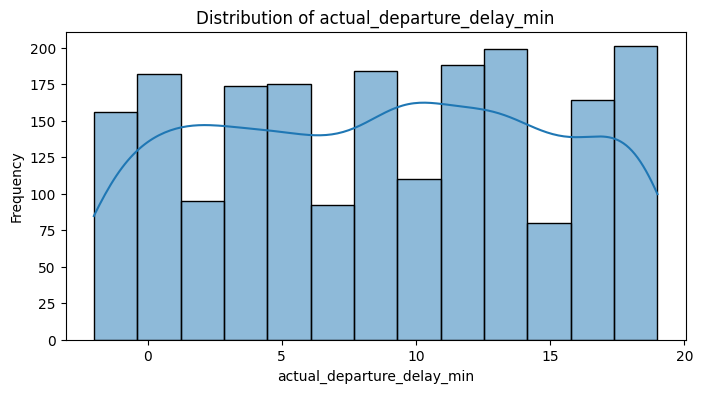

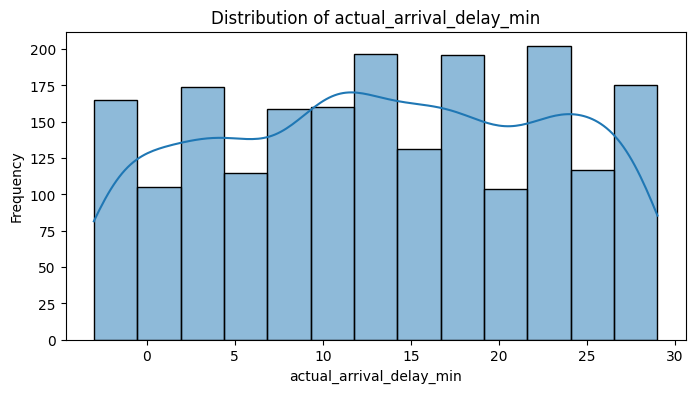

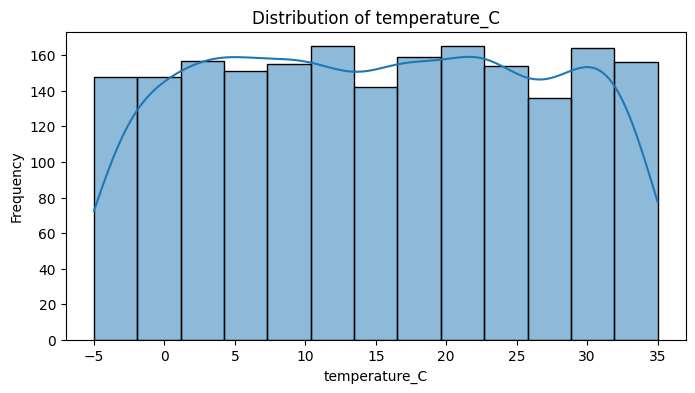

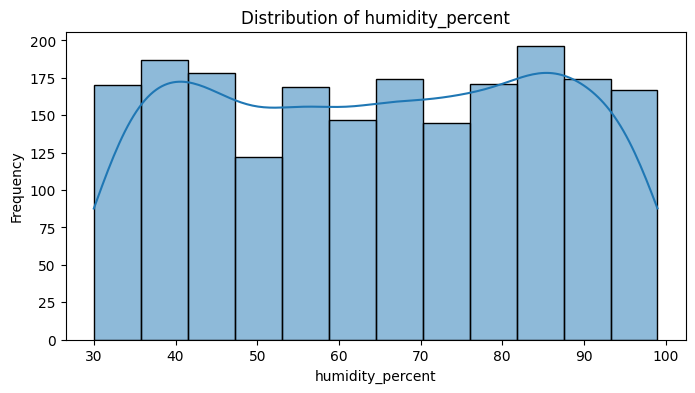

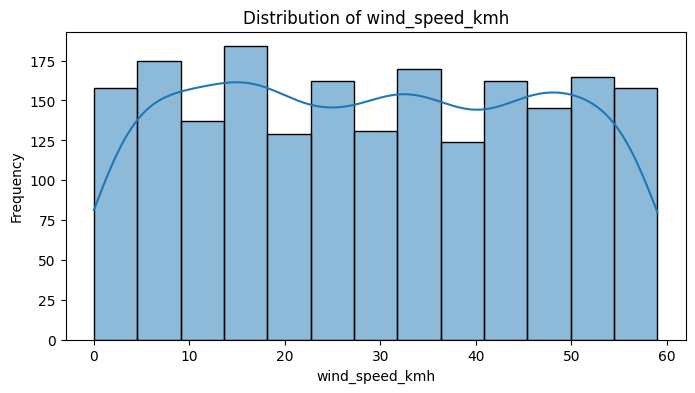

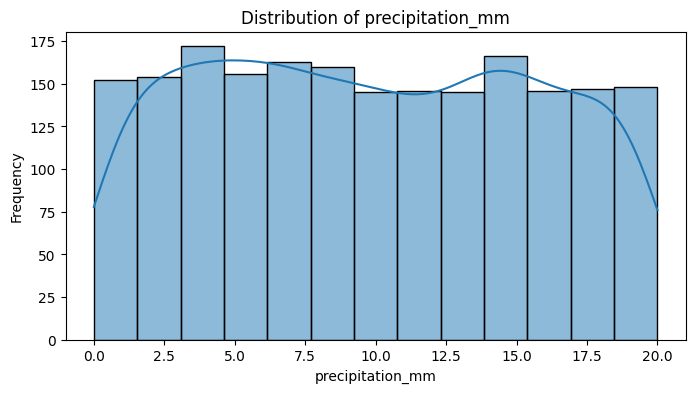

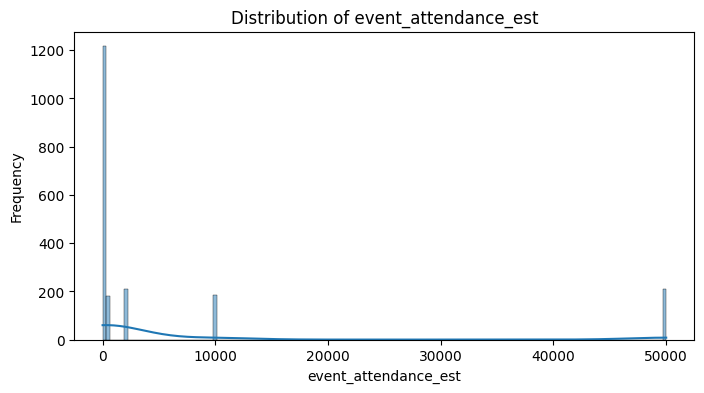

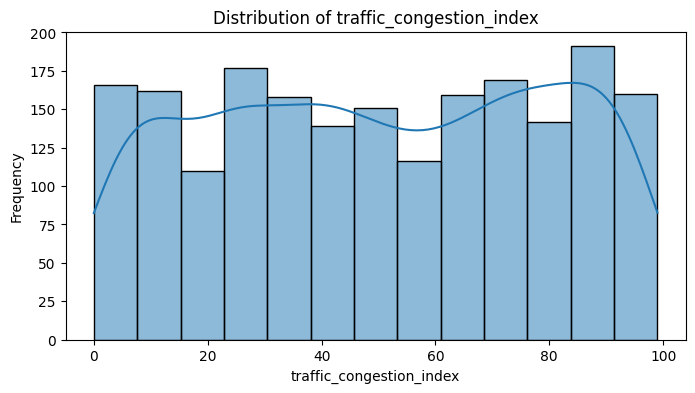

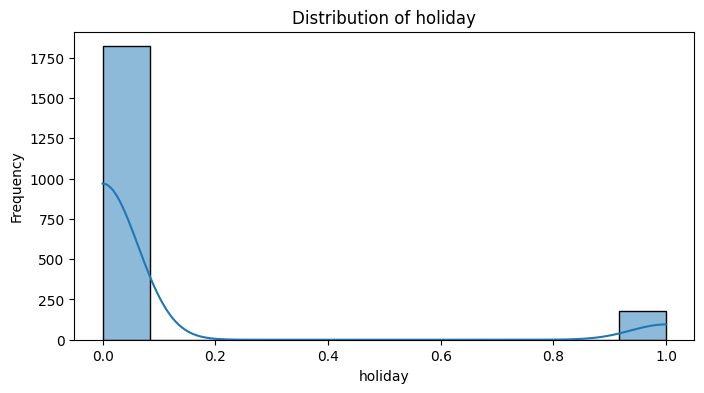

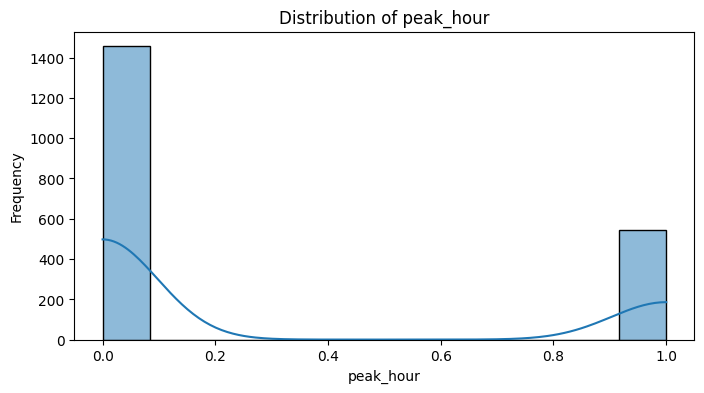

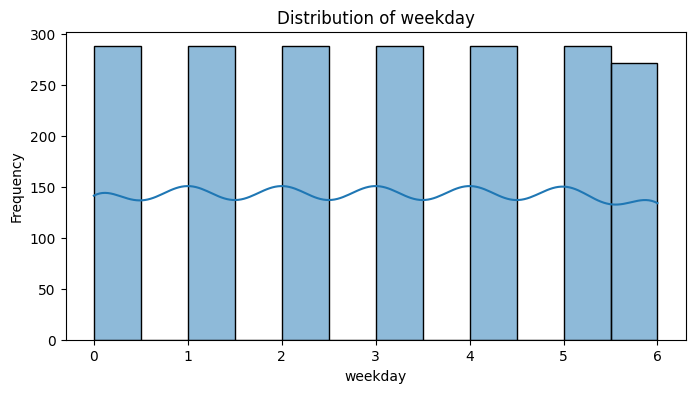

In [111]:
#Distribution of Numerical Variables

#Instead of writing separate code for every column, use a loop.

for col in numeric_features:

    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=df,
        x=col,
        kde=True
    )

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.show()

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


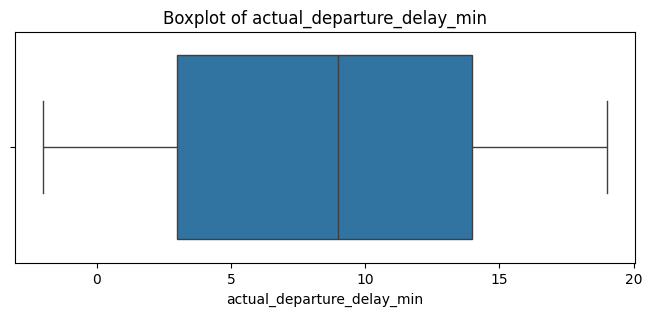

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


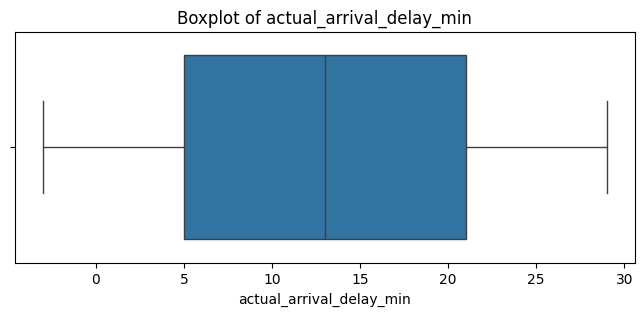

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


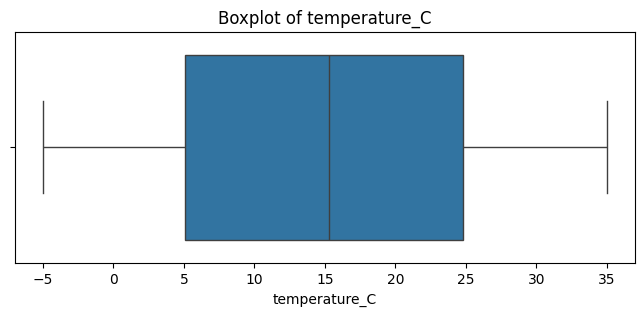

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


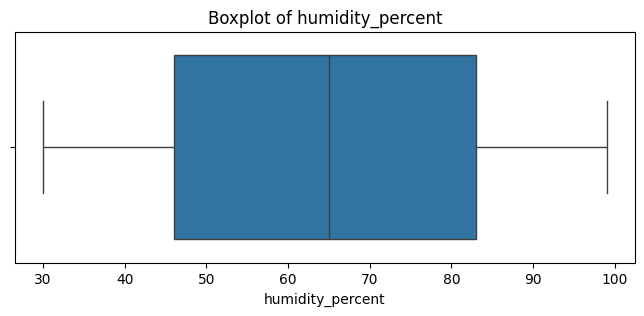

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


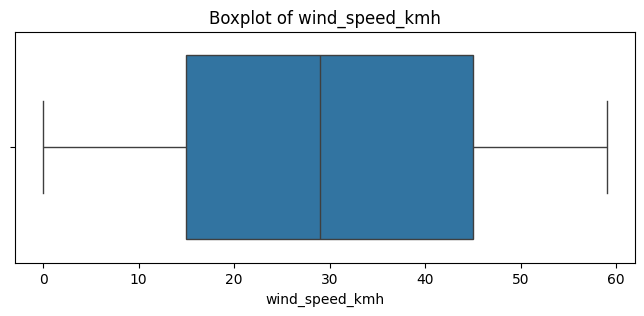

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


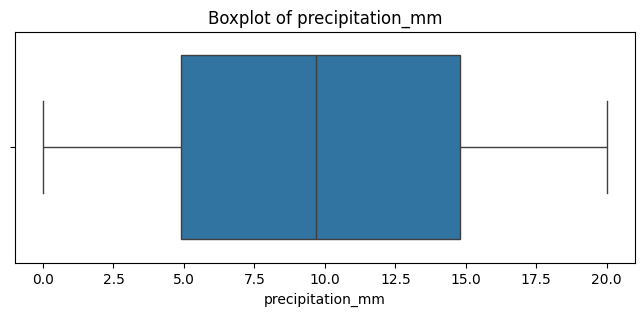

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


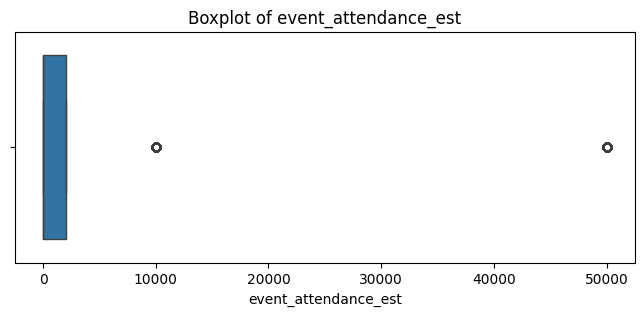

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


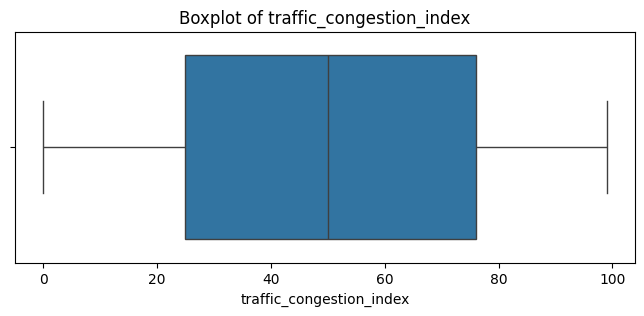

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


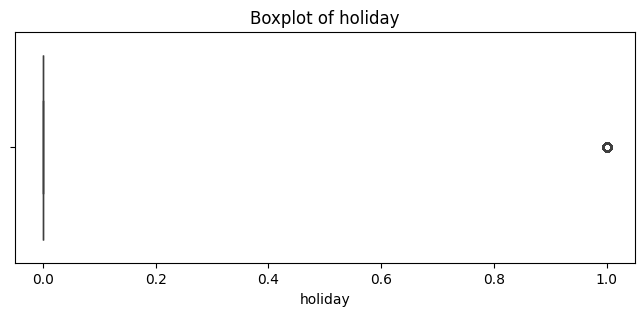

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


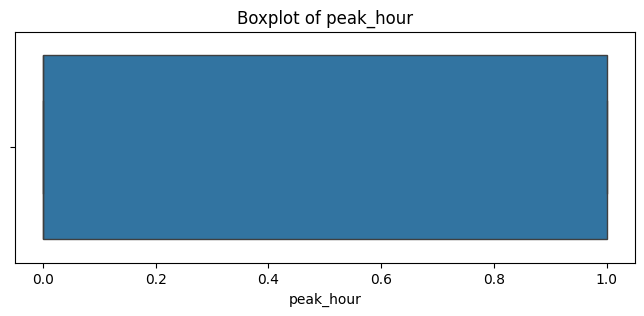

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


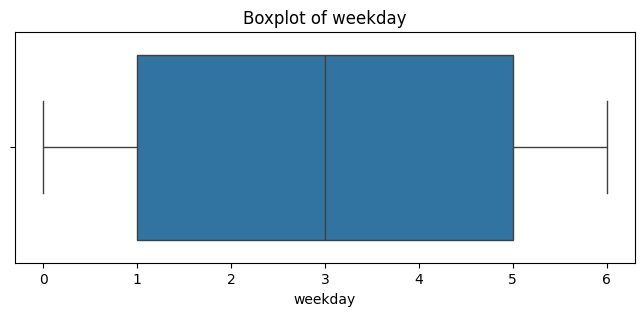

In [112]:
for col in numeric_features:

    plt.figure(figsize=(8, 3))

    sns.boxplot(
        data=df,
        x=col
    )

    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

    plt.show()

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to ge

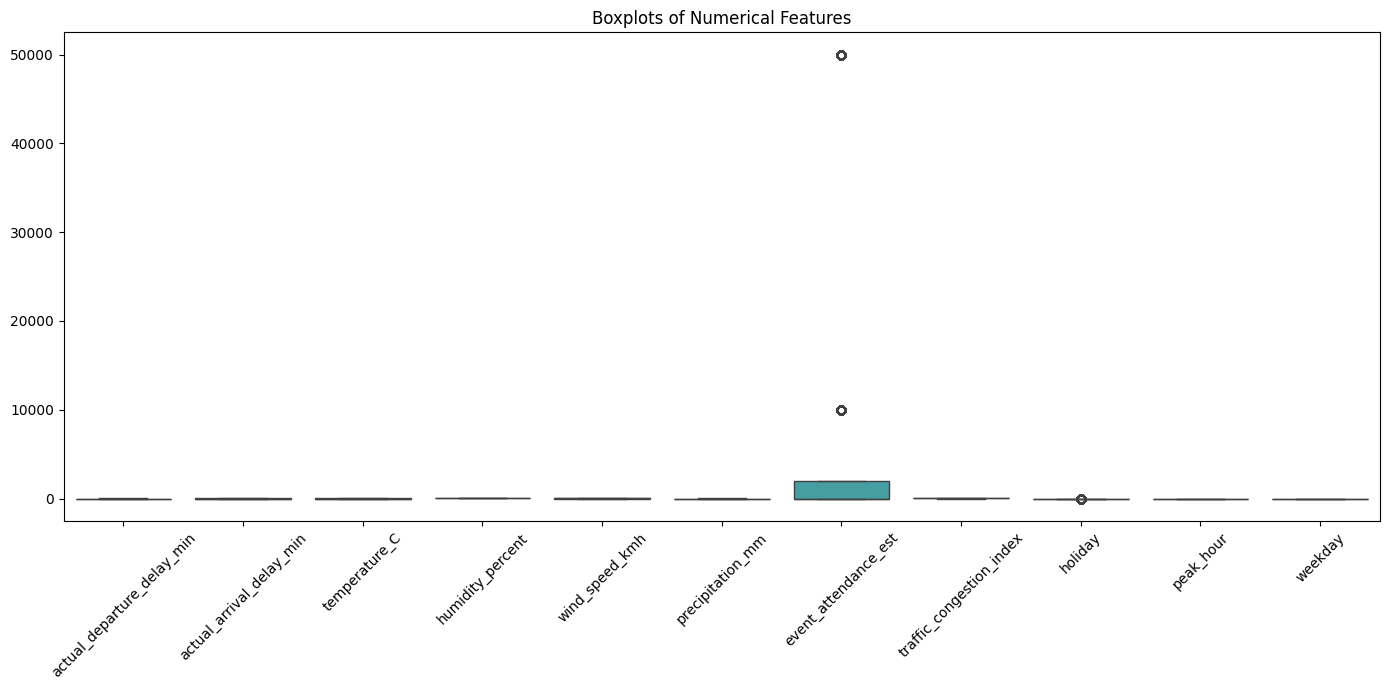

In [113]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df[numeric_features]
)

plt.xticks(rotation=45)

plt.title('Boxplots of Numerical Features')

plt.tight_layout()

plt.show()

### Important Observation: Numerical Representation vs Variable Meaning

Although `holiday`, `peak_hour`, and `weekday` are stored as numerical values,
they represent categorical or ordinal concepts rather than continuous
measurements.

- `holiday` is a binary indicator.
- `peak_hour` is a binary indicator.
- `weekday` represents the day of the week using integer encoding.

Therefore, boxplots are not the most appropriate visualization for these
variables. Countplots and percentage-based categorical analysis will be used
instead.

This distinction is important because data types alone do not always
represent the analytical meaning of a variable.

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


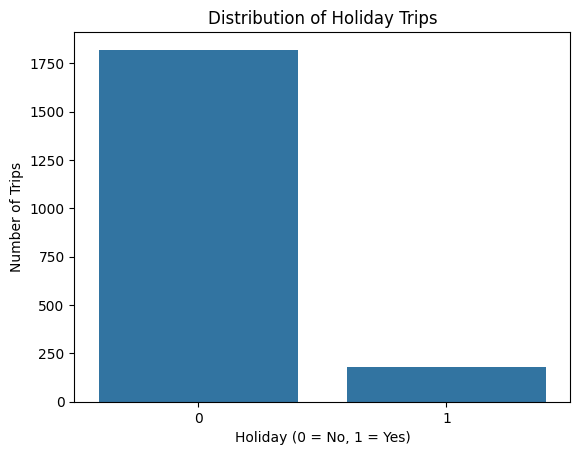

In [114]:
sns.countplot(data=df, x='holiday')

plt.title('Distribution of Holiday Trips')
plt.xlabel('Holiday (0 = No, 1 = Yes)')
plt.ylabel('Number of Trips')

plt.show()

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


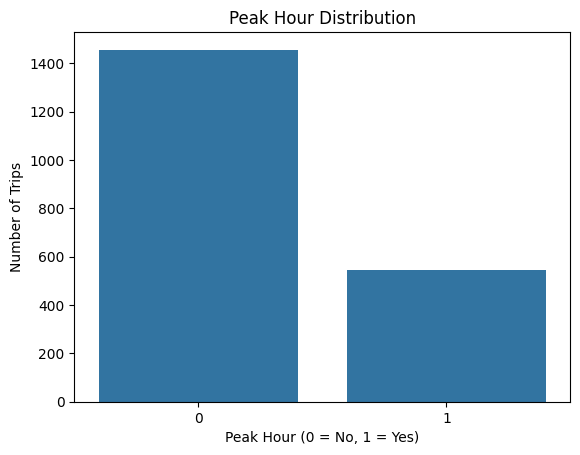

In [115]:
sns.countplot(data=df, x='peak_hour')

plt.title('Peak Hour Distribution')
plt.xlabel('Peak Hour (0 = No, 1 = Yes)')
plt.ylabel('Number of Trips')

plt.show()

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


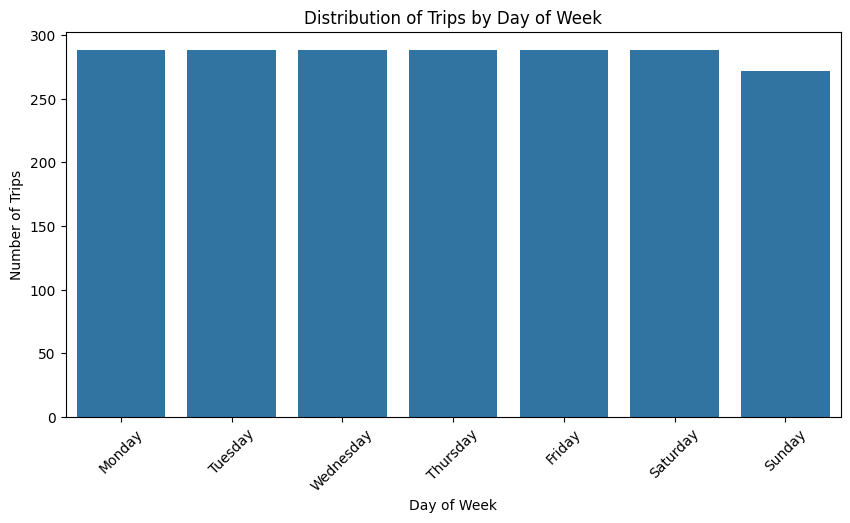

In [116]:
weekday_labels = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}

weekday_counts = df['weekday'].map(weekday_labels)

plt.figure(figsize=(10,5))

sns.countplot(
    x=weekday_counts,
    order=[
        'Monday',
        'Tuesday',
        'Wednesday',
        'Thursday',
        'Friday',
        'Saturday',
        'Sunday'
    ]
)

plt.title('Distribution of Trips by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')

plt.xticks(rotation=45)

plt.show()

In [117]:
numeric_features = [
    col for col in numeric_cols
    if col not in ['delayed', 'holiday', 'peak_hour', 'weekday']
]

print("Continuous Numerical Features:")
print(numeric_features)

Continuous Numerical Features:
['actual_departure_delay_min', 'actual_arrival_delay_min', 'temperature_C', 'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_attendance_est', 'traffic_congestion_index']


In [118]:
categorical_numeric_features = [
    'holiday',
    'peak_hour',
    'weekday'
]

print("Categorical / Binary Features:")
print(categorical_numeric_features)

Categorical / Binary Features:
['holiday', 'peak_hour', 'weekday']


# Skewness Analysis

In [119]:
skewness = pd.DataFrame({
    'Feature': numeric_features,
    'Skewness': [
        df[col].skew()
        for col in numeric_features
    ]
})

skewness.sort_values(
    by='Skewness',
    ascending=False
)

,Feature,Skewness
6,event_attendance_est,2.426541
5,precipitation_mm,0.042215
4,wind_speed_kmh,0.022274
2,temperature_C,0.000498
3,humidity_percent,-0.024794
0,actual_departure_delay_min,-0.029082
7,traffic_congestion_index,-0.039492
1,actual_arrival_delay_min,-0.053581


In [120]:
# Interpretation of skewness

for index, row in skewness.iterrows():

    feature = row['Feature']
    value = row['Skewness']

    if value > 1:
        interpretation = "Highly right-skewed"

    elif value > 0.5:
        interpretation = "Moderately right-skewed"

    elif value < -1:
        interpretation = "Highly left-skewed"

    elif value < -0.5:
        interpretation = "Moderately left-skewed"

    else:
        interpretation = "Approximately symmetric"

    print(f"{feature}: {value:.3f} → {interpretation}")

actual_departure_delay_min: -0.029 → Approximately symmetric
actual_arrival_delay_min: -0.054 → Approximately symmetric
temperature_C: 0.000 → Approximately symmetric
humidity_percent: -0.025 → Approximately symmetric
wind_speed_kmh: 0.022 → Approximately symmetric
precipitation_mm: 0.042 → Approximately symmetric
event_attendance_est: 2.427 → Highly right-skewed
traffic_congestion_index: -0.039 → Approximately symmetric


### Skewness Analysis – Key Findings

The skewness analysis shows that most numerical variables have values close to zero, indicating approximately symmetric distributions.

The main exception is `event_attendance_est`, which has a skewness of approximately 2.43. This indicates a highly right-skewed distribution.

The right skewness suggests that most observations have relatively lower event attendance, while a smaller number of trips are associated with substantially larger events.

This variable will therefore be examined further using boxplots and distribution plots. During feature engineering and preprocessing, the effect of this skewness will be considered before applying any transformation.

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


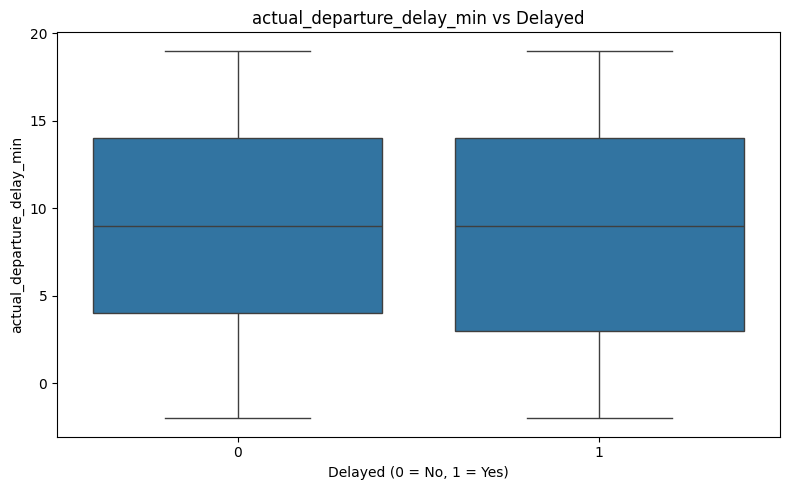

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


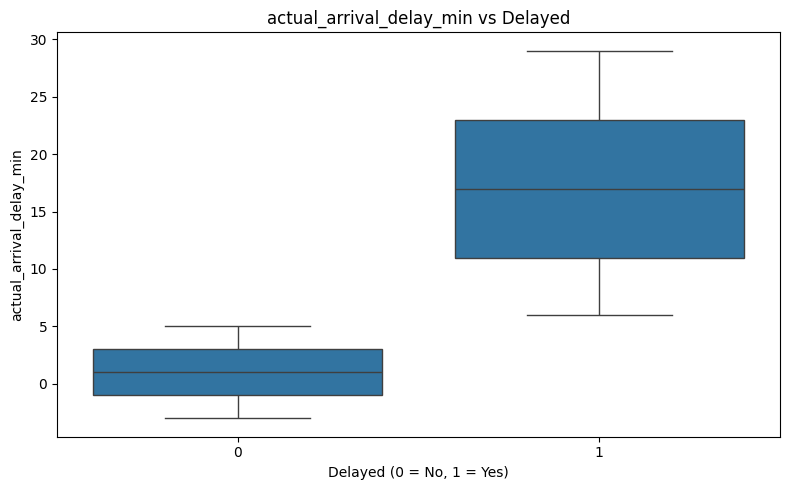

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


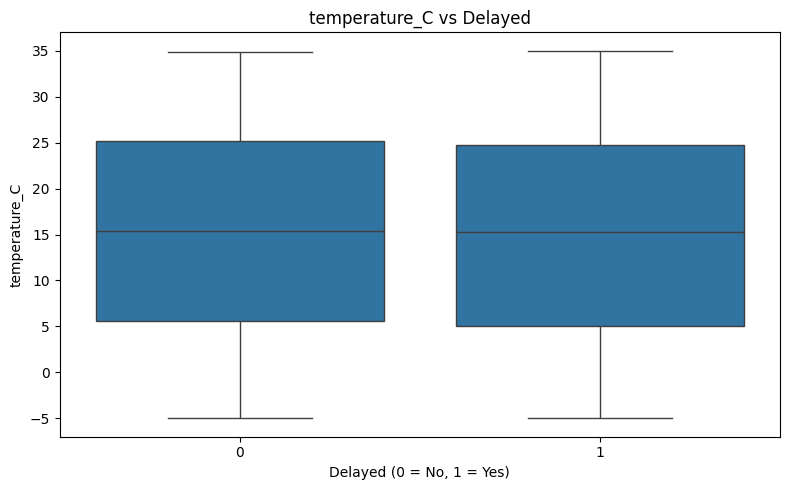

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


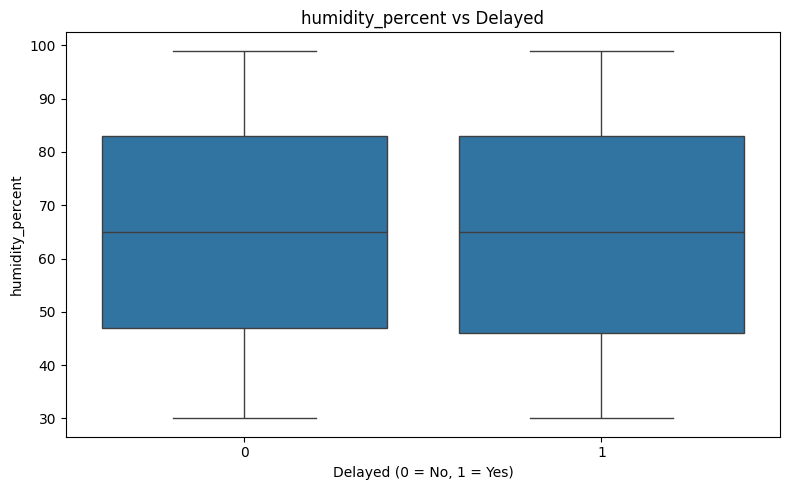

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


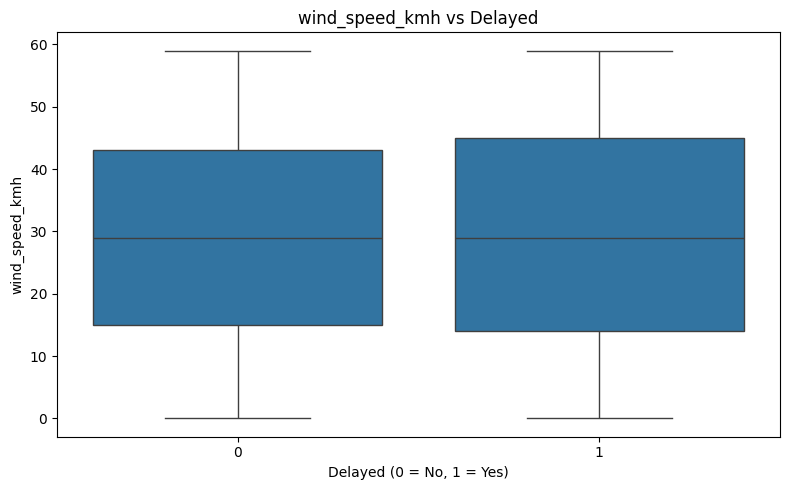

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


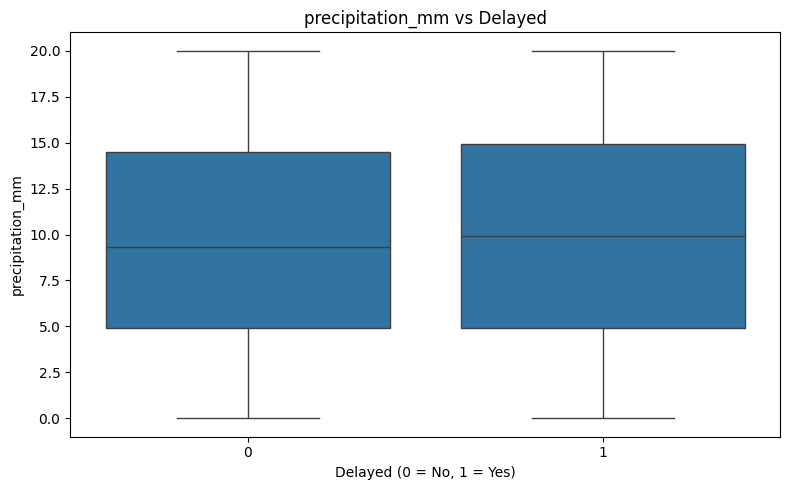

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


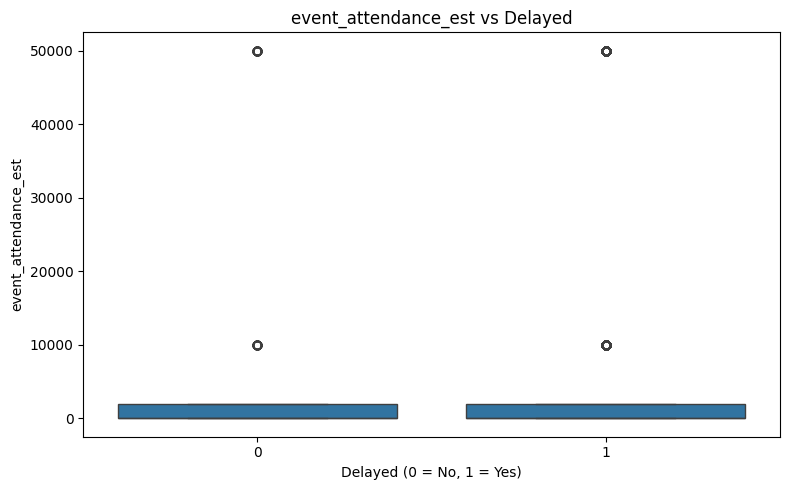

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


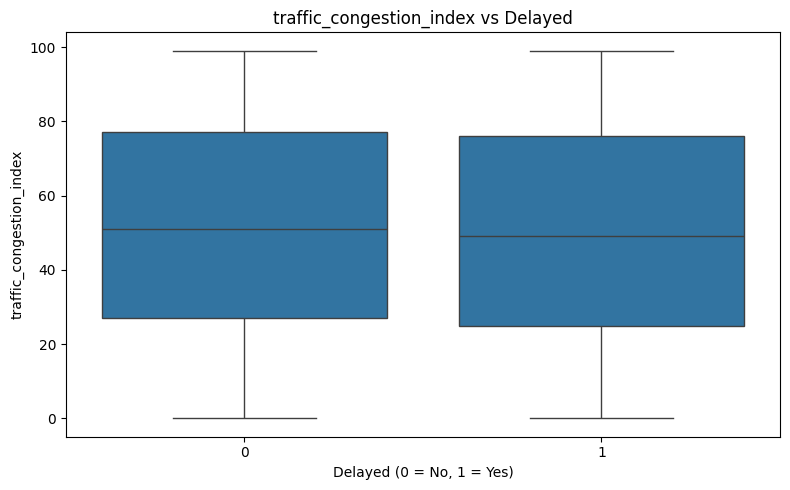

In [121]:
# Numerical Features vs Delay

for col in numeric_features:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x='delayed',
        y=col
    )

    plt.title(f'{col} vs Delayed')
    plt.xlabel('Delayed (0 = No, 1 = Yes)')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

## Numerical Features vs Delay — Boxplots Observations

Boxplots were used to compare numerical feature distributions between
on-time trips (`delayed = 0`) and delayed trips (`delayed = 1`).

### Key Findings

- `actual_arrival_delay_min` shows a very clear separation between the two
  target classes, with delayed trips having substantially higher arrival
  delays.
- `actual_departure_delay_min` shows considerable overlap between the two
  groups.
- `temperature_C`, `humidity_percent`, and `wind_speed_kmh` have very similar
  distributions across both classes.
- `precipitation_mm` shows a slightly higher median for delayed trips, but
  there is substantial overlap between the distributions.
- `event_attendance_est` contains extreme values associated with large events
  and is highly skewed.
- `traffic_congestion_index` shows considerable overlap between delayed and
  on-time trips, indicating that its individual relationship with the target
  may not be strongly linear.

Overall, the boxplots suggest that several individual environmental variables
do not clearly separate delayed from on-time trips. Therefore, correlation,
statistical tests and machine learning models will be used to investigate
non-linear relationships and interactions between features.

`actual_departure_delay_min` and `actual_arrival_delay_min` are treated as
post-trip variables and will not be used as predictors in the final pre-trip
delay prediction model to avoid target leakage.

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


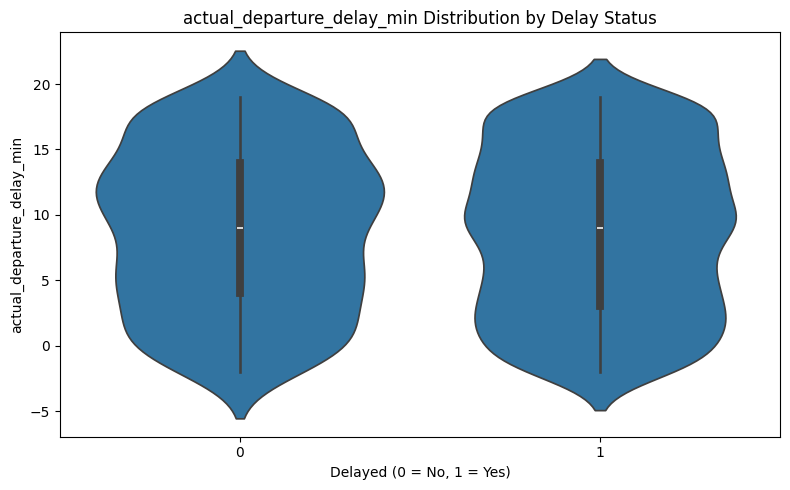

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


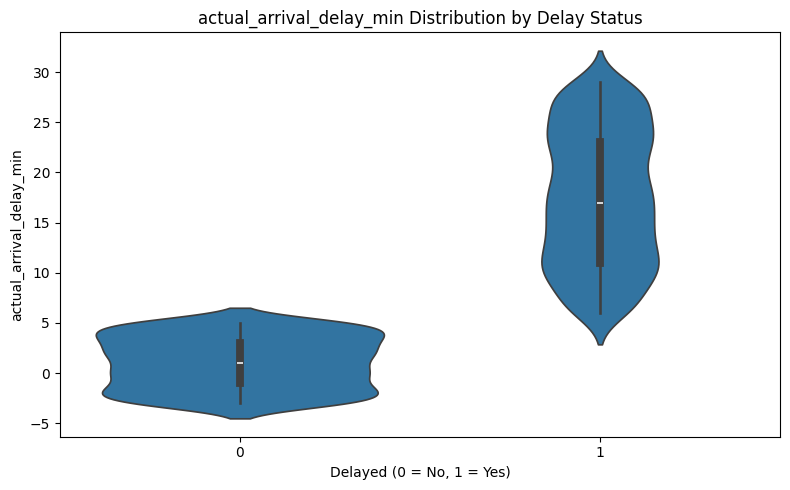

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


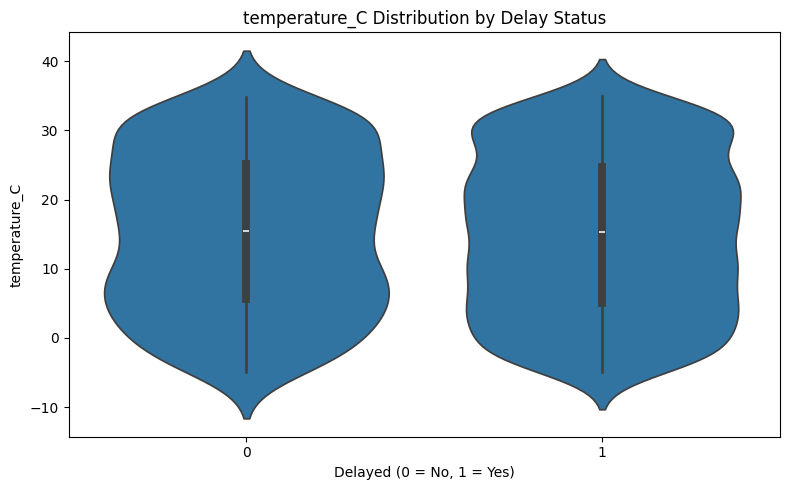

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


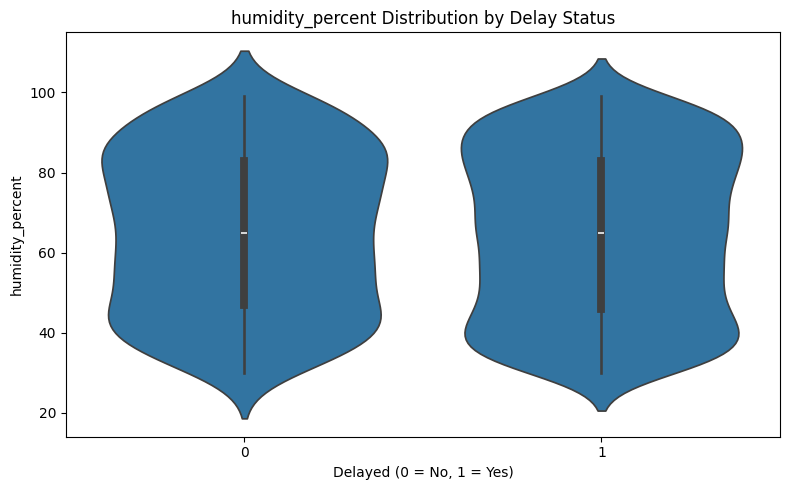

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


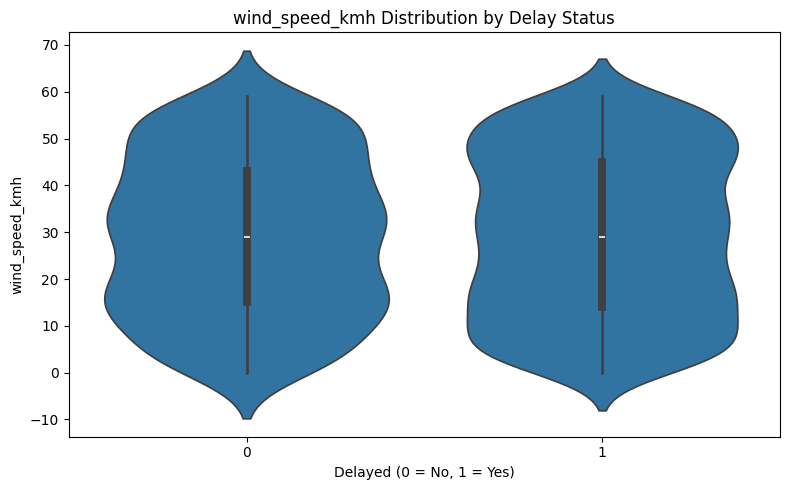

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


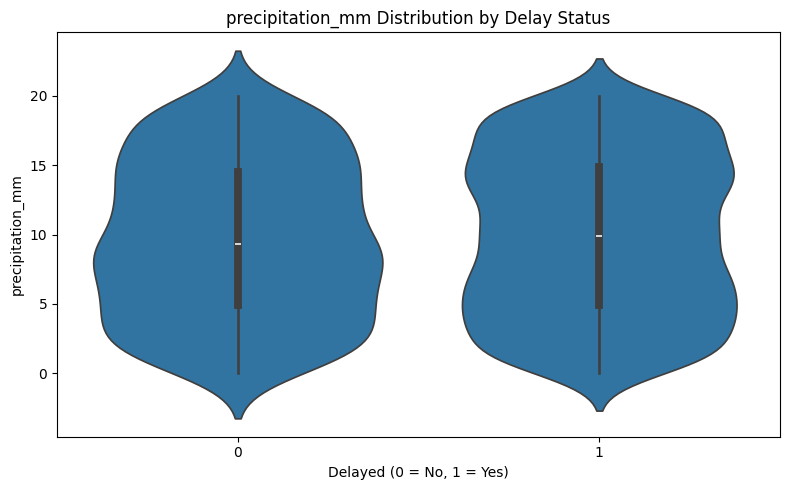

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


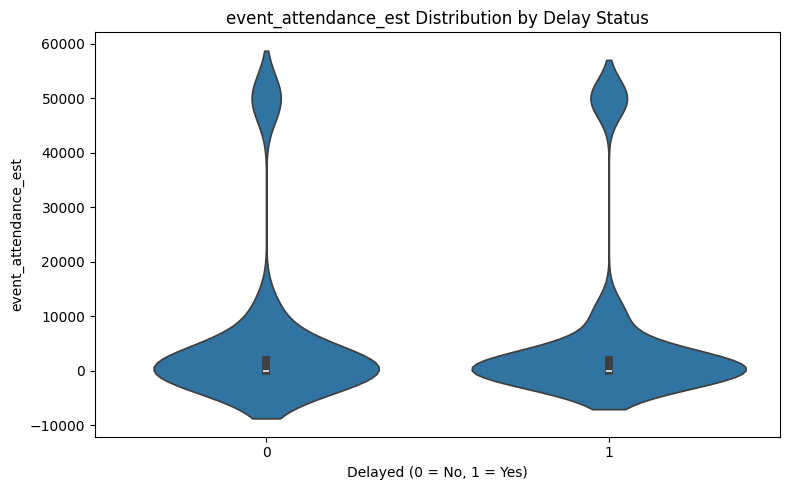

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


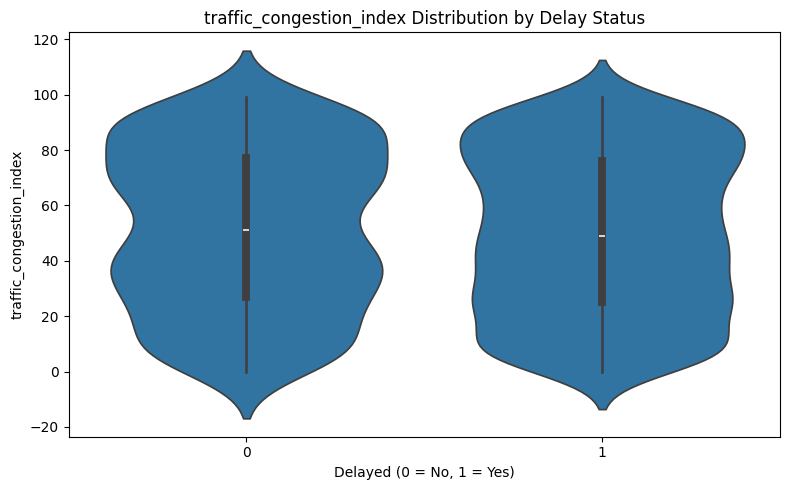

In [122]:
#Numerical Features vs Delay — violin plots

for col in numeric_features:

    plt.figure(figsize=(8, 5))

    sns.violinplot(
        data=df,
        x='delayed',
        y=col
    )

    plt.title(f'{col} Distribution by Delay Status')
    plt.xlabel('Delayed (0 = No, 1 = Yes)')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

## Violin Plot Analysis — Numerical Features vs Delay

Violin plots were used to examine the complete distribution of numerical
features across on-time (`delayed = 0`) and delayed (`delayed = 1`) trips.

The distributions of temperature, humidity, wind speed, precipitation and
traffic congestion show substantial overlap between the two target classes.
This indicates that these variables may have limited individual ability to
separate delayed from on-time trips.

Event attendance shows substantial variability and extreme values, reflecting
the presence of large public events. Its distribution should therefore be
considered carefully during feature engineering.

In contrast, actual arrival delay shows a clear separation between the two
classes, with delayed trips having substantially higher arrival delay values.
However, actual arrival delay is a post-trip measurement and would introduce
target leakage if used to predict whether a trip will be delayed before the
trip occurs.

Overall, the violin plots suggest that delay prediction is unlikely to depend
on a single environmental variable. Combinations of scheduling, traffic,
weather, events and other contextual features may provide more useful
predictive information.

In [123]:
# Mean comparison
numeric_delay_mean = (
    df.groupby('delayed')[numeric_features]
    .mean()
    .T
)

numeric_delay_mean.columns = [
    'On_Time_Mean',
    'Delayed_Mean'
]

numeric_delay_mean

,On_Time_Mean,Delayed_Mean
actual_departure_delay_min,8.798403,8.651101
actual_arrival_delay_min,1.049900,17.418279
temperature_C,15.326547,15.052769
humidity_percent,65.219561,64.545030
wind_speed_kmh,29.143713,29.352902
precipitation_mm,9.597804,9.948566
event_attendance_est,6328.343313,6450.967312
traffic_congestion_index,51.425150,49.849233


## Numerical Features vs Delay — Mean Comparison

The mean values of the numerical variables were compared between on-time
(`delayed = 0`) and delayed (`delayed = 1`) trips.

The most substantial difference was observed for `actual_arrival_delay_min`.
On-time trips had an average arrival delay of approximately 1.05 minutes,
whereas delayed trips had an average of approximately 17.42 minutes.

The environmental variables showed relatively small differences between the
two groups. Temperature, humidity and wind speed had almost identical means.
Precipitation and event attendance were slightly higher for delayed trips.

Interestingly, the mean traffic congestion index was slightly lower for
delayed trips than for on-time trips. Therefore, the descriptive statistics
alone do not support a simple positive relationship between congestion and
delay status.

These results indicate that individual numerical features may not be
sufficient to explain delay status and that interactions between scheduling,
weather, events, traffic and other contextual factors should be investigated.

`actual_departure_delay_min` and `actual_arrival_delay_min` will be excluded
from the final pre-trip prediction model because they represent information
that becomes available after the trip and may introduce target leakage.

In [124]:
#Median comparison

numeric_delay_median = (
    df.groupby('delayed')[numeric_features]
    .median()
    .T
)

numeric_delay_median.columns = [
    'On_Time_Median',
    'Delayed_Median'
]

numeric_delay_median

,On_Time_Median,Delayed_Median
actual_departure_delay_min,9.0,9.0
actual_arrival_delay_min,1.0,17.0
temperature_C,15.4,15.3
humidity_percent,65.0,65.0
wind_speed_kmh,29.0,29.0
precipitation_mm,9.3,9.9
event_attendance_est,0.0,0.0
traffic_congestion_index,51.0,49.0


In [125]:
#Difference between delayed and on-time trips

numeric_comparison = pd.DataFrame({
    'On_Time_Mean': df[df['delayed'] == 0][numeric_features].mean(),
    'Delayed_Mean': df[df['delayed'] == 1][numeric_features].mean()
})

numeric_comparison['Difference'] = (
    numeric_comparison['Delayed_Mean']
    - numeric_comparison['On_Time_Mean']
)

numeric_comparison['Percentage_Difference'] = (
    numeric_comparison['Difference']
    / numeric_comparison['On_Time_Mean'].replace(0, np.nan)
) * 100

numeric_comparison.sort_values(
    'Percentage_Difference',
    ascending=False
)

,On_Time_Mean,Delayed_Mean,Difference,Percentage_Difference
actual_arrival_delay_min,1.049900,17.418279,16.368379,1559.041389
precipitation_mm,9.597804,9.948566,0.350761,3.654600
event_attendance_est,6328.343313,6450.967312,122.623998,1.937695
wind_speed_kmh,29.143713,29.352902,0.209189,0.717786
humidity_percent,65.219561,64.545030,-0.674531,-1.034246
actual_departure_delay_min,8.798403,8.651101,-0.147302,-1.674195
temperature_C,15.326547,15.052769,-0.273778,-1.786302
traffic_congestion_index,51.425150,49.849233,-1.575917,-3.064487


### Median Comparison — Key Observations

Median values were compared between on-time and delayed trips to reduce the
influence of extreme observations.

The largest difference was observed in `actual_arrival_delay_min`, where the
median was 1 minute for on-time trips and 17 minutes for delayed trips. This
strong separation confirms the distributional difference observed in the
violin and boxplots.

Temperature, humidity and wind speed had identical or nearly identical
medians across the two groups, indicating limited differences in their central
values.

Precipitation showed a small increase in median value for delayed trips.

The median of `event_attendance_est` was 0 for both groups. This is likely
because the variable is highly skewed, with most observations concentrated at
low attendance values and a smaller number of very large events. Therefore,
the median alone is not sufficient to assess the effect of event attendance.

Traffic congestion had a median of 51 for on-time trips and 49 for delayed
trips, again showing no simple positive relationship between congestion and
delay status.

Overall, the median comparison supports the visual EDA findings while
highlighting the importance of considering skewness and distribution shape
rather than relying on a single summary statistic.

In [126]:
#Correlation of numerical variables with delay

numeric_target_corr = (
    df[numeric_features + ['delayed']]
    .corr()['delayed']
    .drop('delayed')
    .sort_values(
        key=abs,
        ascending=False
    )
)

numeric_target_corr

actual_arrival_delay_min      0.763662
precipitation_mm              0.026295
traffic_congestion_index     -0.023370
humidity_percent             -0.014377
temperature_C                -0.010337
actual_departure_delay_min   -0.010185
wind_speed_kmh                0.005252
event_attendance_est          0.003497
Name: delayed, dtype: float64

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


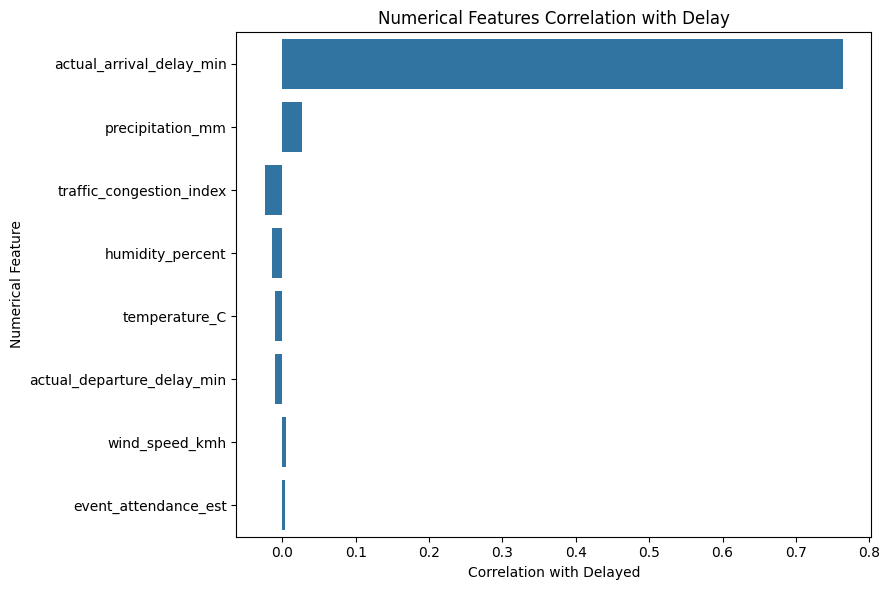

In [127]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=numeric_target_corr.values,
    y=numeric_target_corr.index
)

plt.title('Numerical Features Correlation with Delay')
plt.xlabel('Correlation with Delayed')
plt.ylabel('Numerical Feature')

plt.tight_layout()
plt.show()

## Correlation Analysis: Numerical Features vs Delay Status

Pearson correlation was used to examine the linear relationship between
numerical variables and the binary target variable `delayed`.

The strongest correlation was observed for `actual_arrival_delay_min`
(r = 0.764), indicating a strong positive association with delay status.
However, this variable represents information available after the journey
and therefore introduces target leakage. It will not be used as a predictor
in the final pre-trip classification model.

The remaining numerical variables showed very weak correlations with the
target. `precipitation_mm` had the highest correlation among the potential
predictive variables (r = 0.026), followed by `traffic_congestion_index`
(r = -0.023). Temperature, humidity, wind speed and event attendance showed
near-zero linear correlations.

The weak individual correlations do not necessarily indicate that these
variables have no predictive value. Delay behaviour may depend on
non-linear relationships and interactions between weather, traffic,
events, transport type, scheduling and temporal factors. Therefore,
correlation analysis will be complemented by categorical analysis,
statistical significance testing and machine learning models.

In [128]:
#Statistical comparison

#We can also test whether numerical variables differ significantly between delayed and on-time trips.

from scipy.stats import ttest_ind

statistical_results = []

for col in numeric_features:

    on_time = df.loc[
        df['delayed'] == 0,
        col
    ].dropna()

    delayed = df.loc[
        df['delayed'] == 1,
        col
    ].dropna()

    statistic, p_value = ttest_ind(
        on_time,
        delayed,
        equal_var=False
    )

    statistical_results.append({
        'Feature': col,
        'T-Statistic': statistic,
        'P-Value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

statistical_results = pd.DataFrame(
    statistical_results
)

statistical_results.sort_values(
    'P-Value'
)

,Feature,T-Statistic,P-Value,Significant
1,actual_arrival_delay_min,-77.880661,0.000000,Yes
5,precipitation_mm,-1.194007,0.232796,No
7,traffic_congestion_index,1.044199,0.296688,No
3,humidity_percent,0.653386,0.513678,No
2,temperature_C,0.461633,0.644461,No
0,actual_departure_delay_min,0.460901,0.644984,No
4,wind_speed_kmh,-0.237854,0.812050,No
6,event_attendance_est,-0.156681,0.875533,No


## Statistical Significance Testing

Independent-samples t-tests were performed to determine whether the numerical
features had statistically significant differences between on-time
(`delayed = 0`) and delayed (`delayed = 1`) trips.

A significance level of α = 0.05 was used. Therefore, features with
p-values below 0.05 were considered statistically significant.

The results showed that `actual_arrival_delay_min` was the only numerical
feature with a statistically significant difference between the two groups
(p < 0.001). This is consistent with the strong correlation and substantial
difference in mean and median arrival delay observed during the descriptive
analysis.

None of the remaining numerical variables had statistically significant
differences at the 5% significance level. In particular, precipitation,
traffic congestion, humidity, temperature, wind speed and event attendance
all had p-values greater than 0.05.

However, statistical non-significance in a univariate test does not imply
that a feature has no predictive value. Machine learning models can capture
non-linear relationships and interactions between multiple variables.

`actual_arrival_delay_min` will therefore be excluded from the final
pre-trip prediction model because it represents post-trip information and
would introduce target leakage.

Because `event_attendance_est` is highly right-skewed, additional
non-parametric analysis may be considered to ensure that conclusions are not
dependent on the assumptions of the t-test.

# Categorical Variables

In [154]:
categorical_cols = df.select_dtypes(
    include=['object']
).columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
['trip_id', 'date', 'time', 'transport_type', 'route_id', 'origin_station', 'destination_station', 'scheduled_departure', 'scheduled_arrival', 'weather_condition', 'event_type', 'season']


In [156]:
# Columns that contain date/time information
datetime_cols = [
    'date',
    'time',
    'scheduled_departure',
    'scheduled_arrival'
]

# Identifier column
id_cols = [
    'trip_id'
]

# Remove date/time columns from categorical columns
categorical_cols = [
    col for col in categorical_cols
    if col not in datetime_cols and  
        col not in id_cols
]

print("Categorical Columns:")
print(categorical_cols)

print("\nDate/Time Columns:")
print(datetime_cols)

print ("\nIdentifier Columns:")
print(id_cols)

Categorical Columns:
['transport_type', 'route_id', 'origin_station', 'destination_station', 'weather_condition', 'event_type', 'season']

Date/Time Columns:
['date', 'time', 'scheduled_departure', 'scheduled_arrival']

Identifier Columns:
['trip_id']


In [158]:
#Unique Values in Categorical Variables

for col in categorical_cols:

    print("=" * 60)
    print(f"Column: {col}")
    print(f"Number of Unique Values: {df[col].nunique()}")
    print("\nUnique Values:")
    print(df[col].unique())

Column: transport_type
Number of Unique Values: 4

Unique Values:
['Tram' 'Metro' 'Bus' 'Train']
Column: route_id
Number of Unique Values: 20

Unique Values:
['Route_15' 'Route_12' 'Route_16' 'Route_19' 'Route_8' 'Route_17'
 'Route_5' 'Route_6' 'Route_18' 'Route_9' 'Route_13' 'Route_10' 'Route_7'
 'Route_14' 'Route_20' 'Route_3' 'Route_2' 'Route_11' 'Route_4' 'Route_1']
Column: origin_station
Number of Unique Values: 50

Unique Values:
['Station_31' 'Station_49' 'Station_29' 'Station_26' 'Station_18'
 'Station_32' 'Station_22' 'Station_38' 'Station_17' 'Station_23'
 'Station_24' 'Station_50' 'Station_8' 'Station_41' 'Station_6'
 'Station_5' 'Station_44' 'Station_28' 'Station_11' 'Station_1'
 'Station_43' 'Station_19' 'Station_9' 'Station_27' 'Station_34'
 'Station_4' 'Station_36' 'Station_15' 'Station_13' 'Station_48'
 'Station_12' 'Station_37' 'Station_33' 'Station_25' 'Station_10'
 'Station_47' 'Station_21' 'Station_30' 'Station_20' 'Station_42'
 'Station_39' 'Station_35' 'Station_14

In [162]:
#Frequency Tables 

for col in categorical_cols:

    print("=" * 60)
    print(f"Frequency Table: {col}")

    print(
        df[col]
        .value_counts(dropna=False)
    )

Frequency Table: transport_type
transport_type
Bus      525
Train    493
Tram     491
Metro    491
Name: count, dtype: int64
Frequency Table: route_id
route_id
Route_3     114
Route_15    112
Route_13    112
Route_17    110
Route_2     110
Route_8     109
Route_12    105
Route_14    105
Route_4     104
Route_18    101
Route_9     101
Route_5      98
Route_6      97
Route_20     97
Route_19     95
Route_7      89
Route_11     88
Route_1      87
Route_10     86
Route_16     80
Name: count, dtype: int64
Frequency Table: origin_station
origin_station
Station_17    55
Station_47    51
Station_32    49
Station_40    49
Station_13    49
Station_49    49
Station_28    47
Station_29    47
Station_22    46
Station_45    45
Station_38    45
Station_48    44
Station_15    44
Station_20    43
Station_23    43
Station_43    42
Station_4     42
Station_8     42
Station_19    41
Station_3     41
Station_26    41
Station_21    41
Station_1     40
Station_10    40
Station_25    40
Station_50    39
Stati

In [163]:
# Number of unique values in each categorical variable

categorical_summary = pd.DataFrame({
    'Feature': categorical_cols,
    'Unique Values': [
        df[col].nunique()
        for col in categorical_cols
    ]
})

categorical_summary

,Feature,Unique Values
0,transport_type,4
1,route_id,20
2,origin_station,50
3,destination_station,50
4,weather_condition,6
5,event_type,5
6,season,4


C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


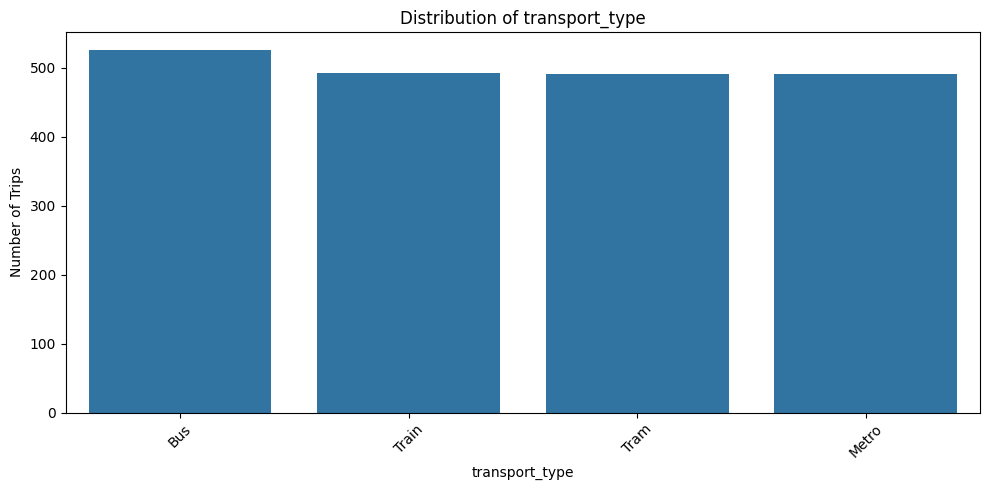

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


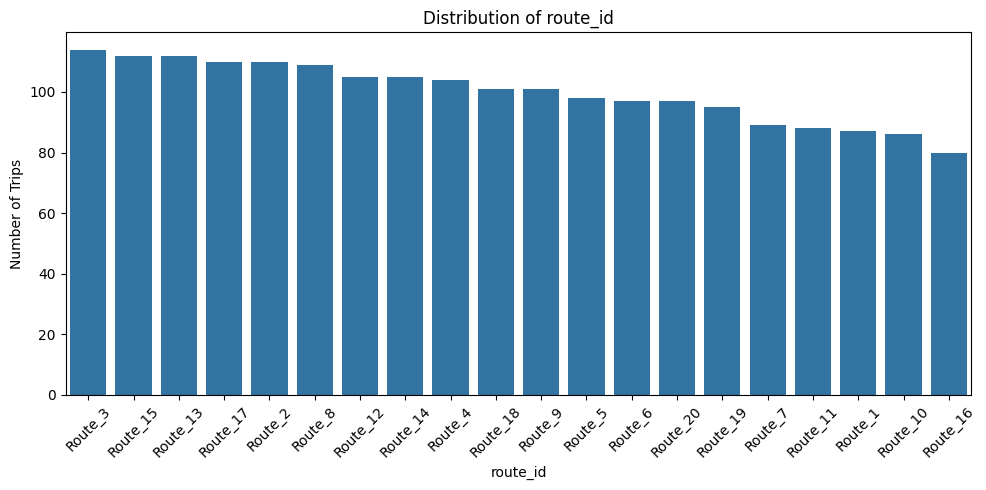

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


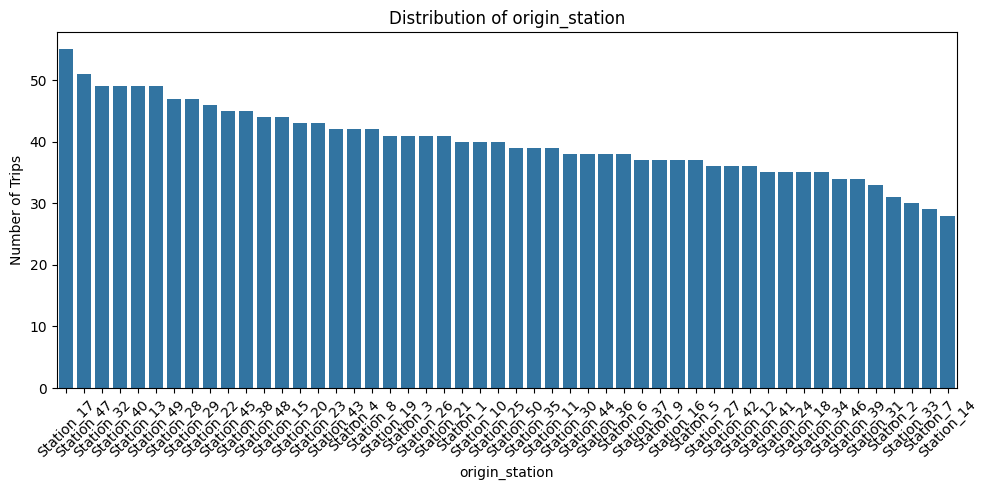

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


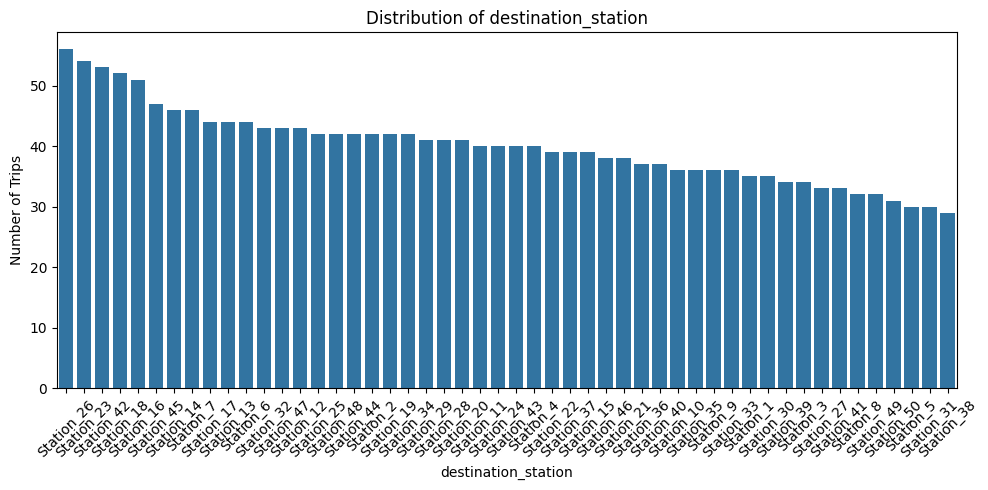

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


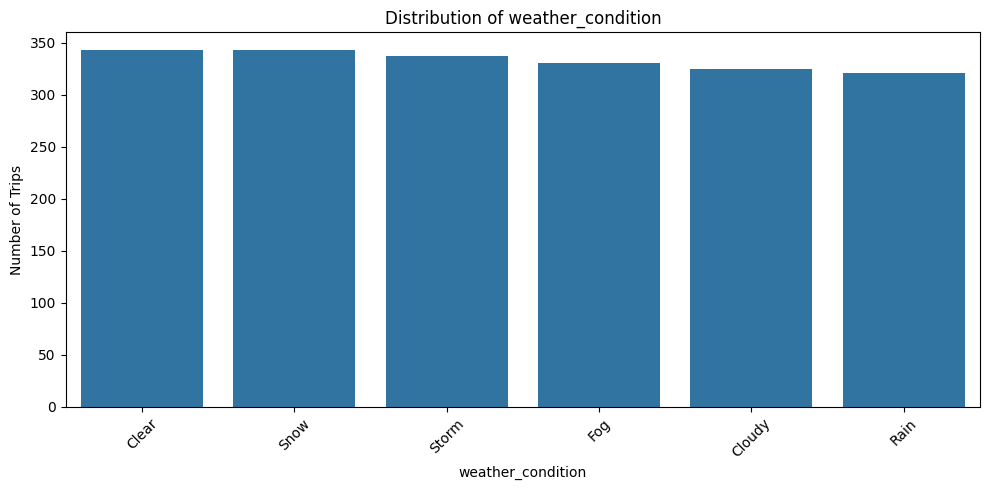

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


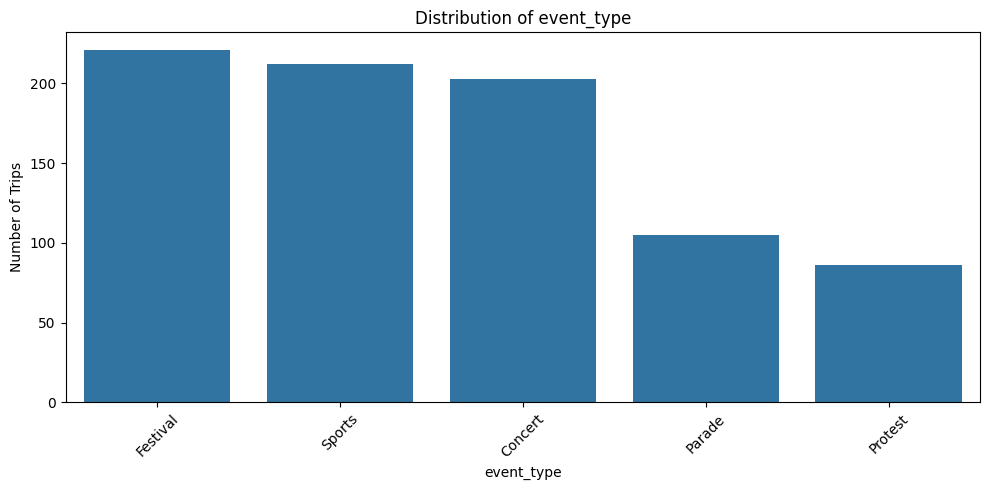

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


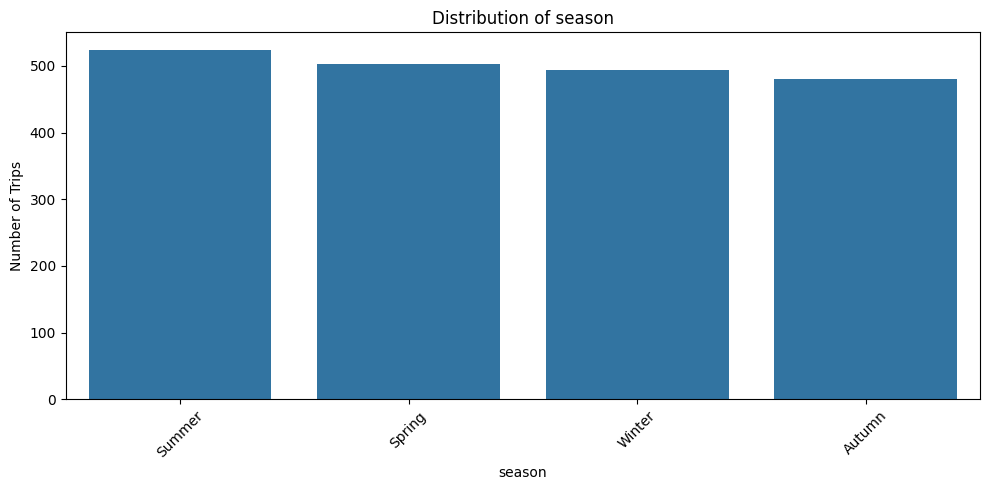

In [169]:
for col in categorical_cols:

    plt.figure(figsize=(10, 5))

    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Number of Trips')

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

In [ ]:
#Transport type percentages

transport_distribution = (
    df['transport_type']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

transport_distribution

transport_type
Bus      26.25
Train    24.65
Tram     24.55
Metro    24.55
Name: proportion, dtype: float64

## Categorical Variable Analysis — Observations

The categorical variables were explored using unique-value analysis, frequency
tables, percentage distributions, and count plots.

### Transport Type

The dataset contains four transport modes: Bus, Train, Tram, and Metro.

The distribution is relatively balanced across the four transport types, with
Bus representing the largest proportion of trips (26.25%), followed by Train
(24.65%), Tram (24.55%), and Metro (24.55%).

This balanced distribution reduces the likelihood of the model being strongly
biased toward a particular transport mode.

### Route ID

There are 20 different routes in the dataset. The number of trips across
routes varies, but no single route dominates the dataset.

This provides sufficient variation for investigating whether particular routes
are associated with different delay patterns.

### Origin and Destination Stations

The dataset contains 50 origin stations and 50 destination stations.

The frequency distributions show that trips are reasonably spread across the
stations, although some stations occur more frequently than others.

Origin and destination stations may capture route-specific or location-specific
patterns that could influence transport delays.

### Weather Condition

Six weather conditions are represented:

- Clear
- Snow
- Storm
- Fog
- Cloudy
- Rain

The frequencies are relatively balanced, with Clear and Snow having the highest
number of observations and Rain having the lowest.

This provides useful variation for analysing the relationship between weather
conditions and transport delays.

### Event Type

The `event_type` variable contains five event categories:

- Festival
- Sports
- Concert
- Parade
- Protest

A substantial number of observations have missing values in this variable.
There are 1,173 missing observations compared with 827 observations associated
with a recorded event.

The missing values should not be removed automatically because they may
represent trips where no major city event was taking place. This will be
investigated and handled appropriately during the preprocessing stage.

### Season

The dataset contains four seasons:

- Summer
- Spring
- Winter
- Autumn

The distribution across seasons is relatively balanced, with Summer having the
highest number of observations and Autumn the lowest.

This allows seasonal patterns in transport delays to be investigated.

### Overall Finding

Overall, the categorical variables provide good variation across transport
types, routes, stations, weather conditions, events, and seasons.

The relatively balanced distributions are useful for machine learning.
However, the high proportion of missing values in `event_type` requires
specific treatment during data preprocessing.

The next stage of the analysis will investigate how these categorical
variables relate to the target variable `delayed`.

# Categorical Variables vs Target — Delay Analysis


Delay Rate by transport_type


,transport_type,delay_rate_percent
0,Train,76.88
1,Tram,76.37
2,Bus,75.24
3,Metro,71.28


C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


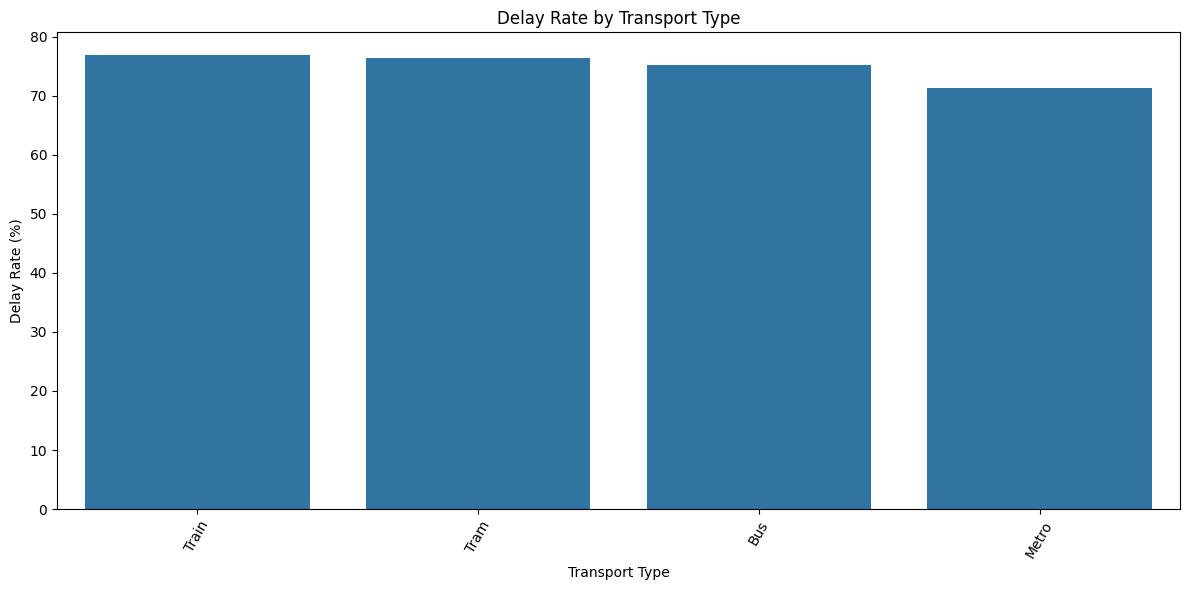


Delay Rate by route_id


,route_id,delay_rate_percent
0,Route_12,80.00
1,Route_7,79.78
2,Route_17,78.18
3,Route_15,77.68
4,Route_2,77.27
5,Route_19,76.84
6,Route_6,76.29
7,Route_9,76.24
8,Route_5,75.51
9,Route_20,75.26


C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


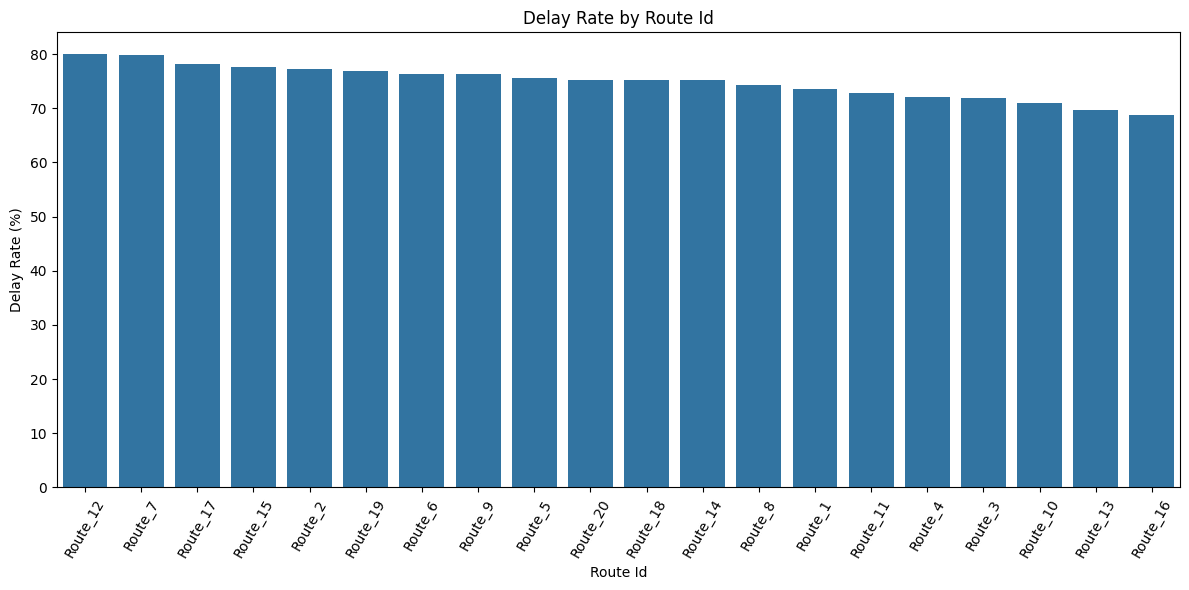


Delay Rate by origin_station


,origin_station,delay_rate_percent
0,Station_14,89.29
1,Station_17,85.45
2,Station_35,84.62
3,Station_48,84.09
4,Station_16,83.78
5,Station_21,82.93
6,Station_22,82.61
7,Station_4,80.95
8,Station_26,80.49
9,Station_24,80.00


C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


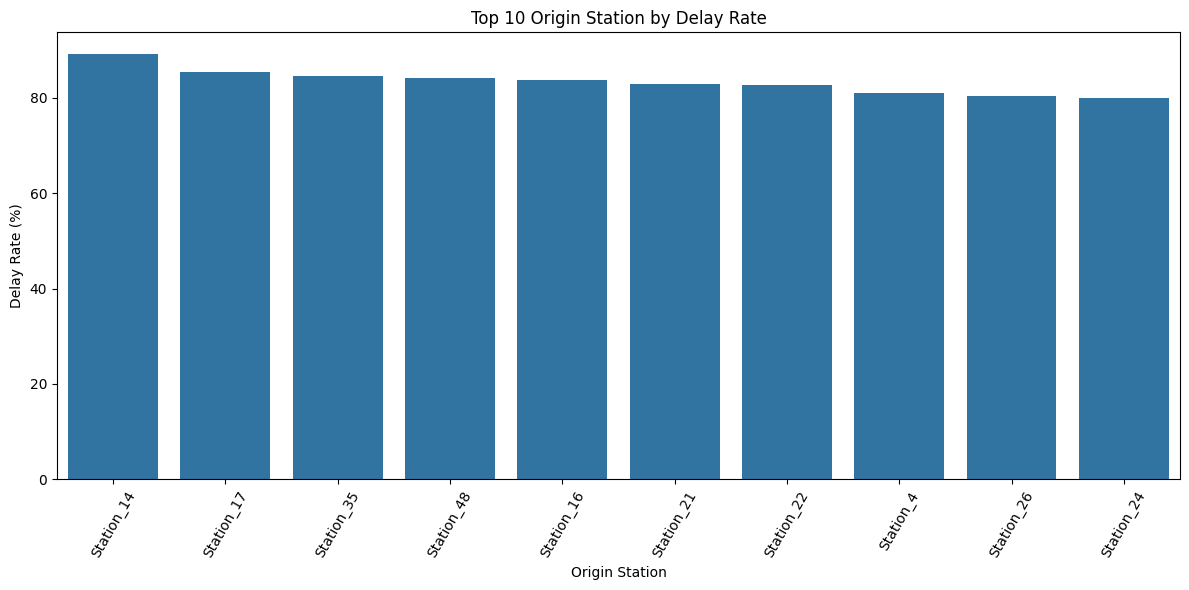


Delay Rate by destination_station


,destination_station,delay_rate_percent
0,Station_31,90.00
1,Station_13,88.64
2,Station_3,88.24
3,Station_25,85.71
4,Station_27,84.85
5,Station_15,84.62
6,Station_17,84.09
7,Station_20,82.93
8,Station_7,82.61
9,Station_6,81.82


C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


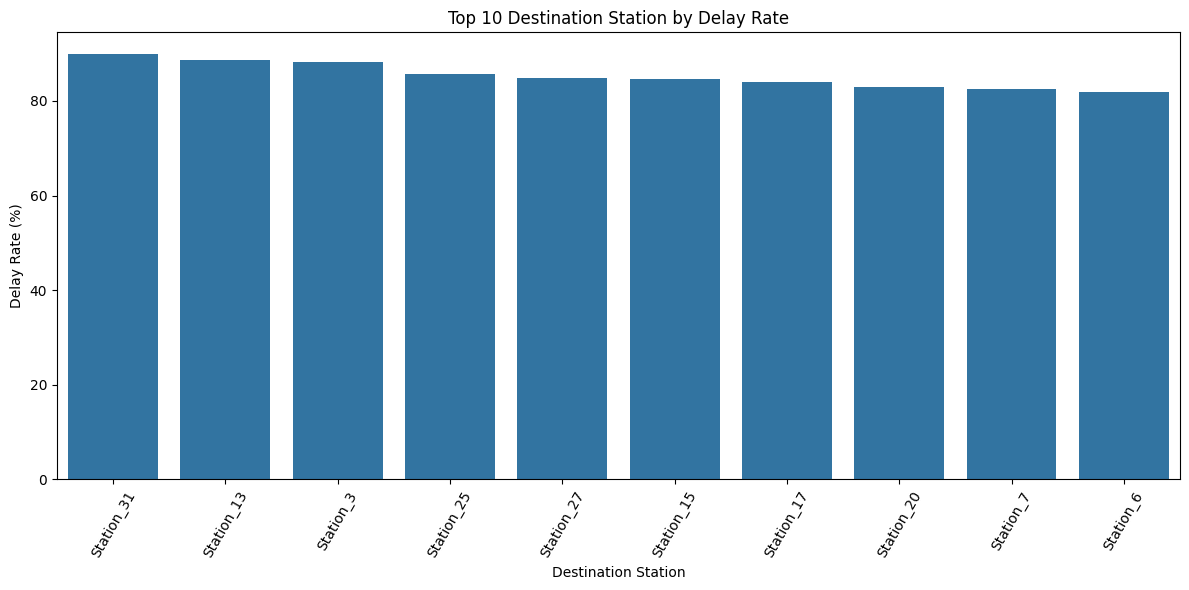


Delay Rate by weather_condition


,weather_condition,delay_rate_percent
0,Storm,76.56
1,Rain,75.70
2,Clear,75.51
3,Snow,75.22
4,Cloudy,73.54
5,Fog,73.11


C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


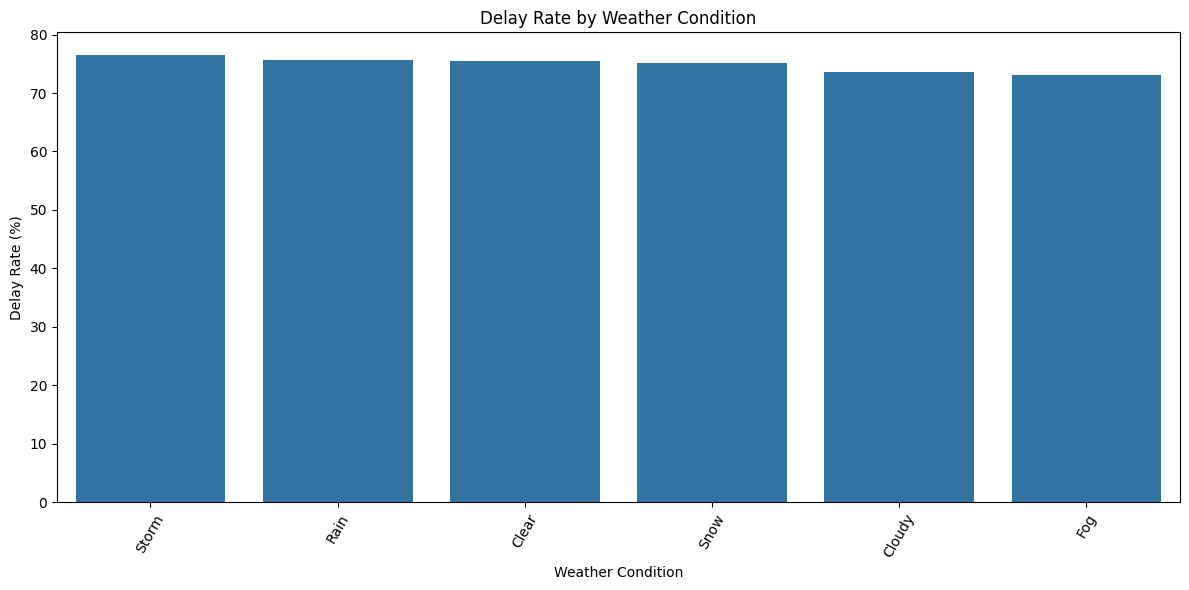


Delay Rate by event_type


,event_type,delay_rate_percent
0,Protest,76.74
1,Parade,76.19
2,Unknown / Missing Event,75.53
3,Festival,74.66
4,Concert,73.40
5,Sports,72.17


C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


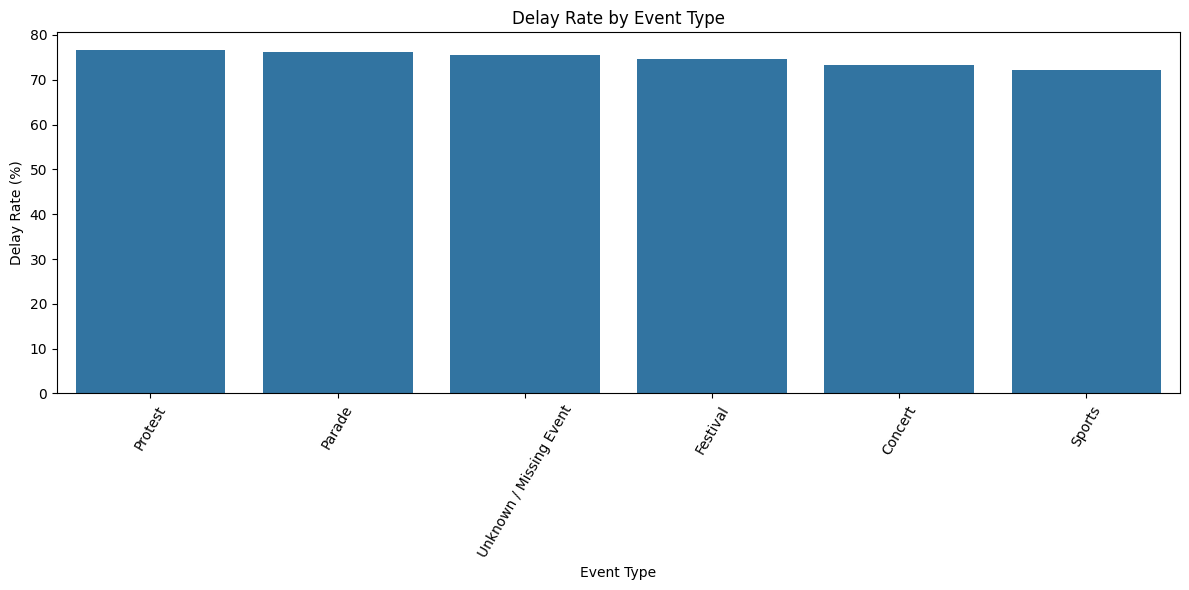


Delay Rate by season


,season,delay_rate_percent
0,Winter,76.32
1,Autumn,75.62
2,Spring,74.90
3,Summer,73.09


C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


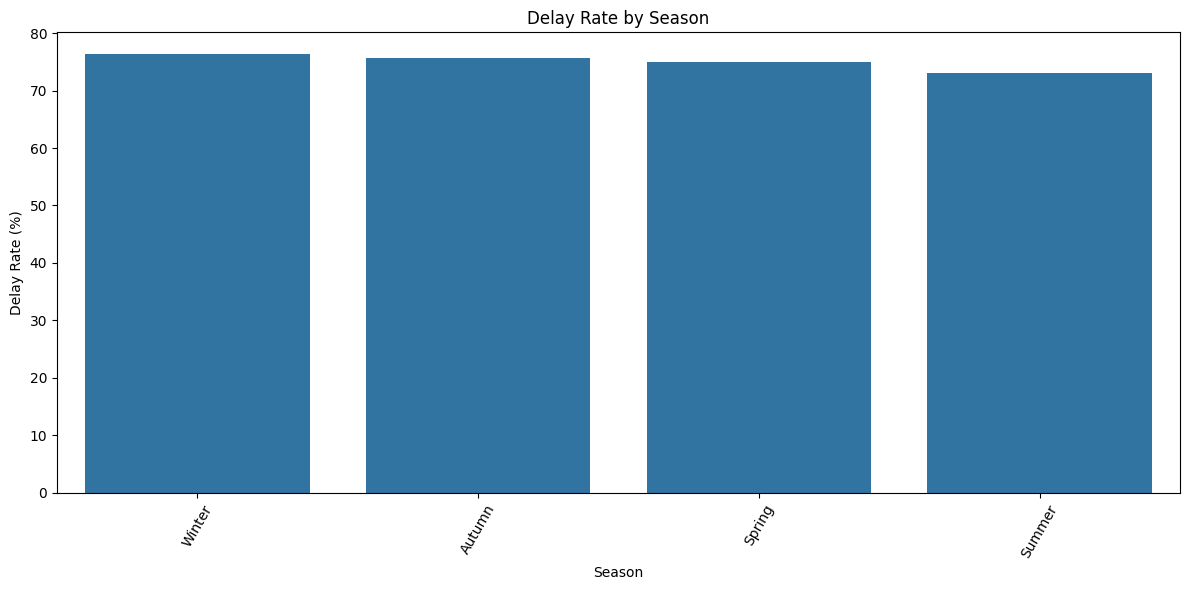

In [185]:
# Categorical variables vs target variable



# Create a copy for analysis
df_cat = df.copy()

# Treat missing event types as "No Event"
df_cat['event_type'] = df_cat['event_type'].fillna('Unknown / Missing Event')

for column in categorical_cols:
    
    delay_rate = (
        df_cat.groupby(column)['delayed']
        .mean()
        .mul(100)
        .sort_values(ascending=False)
        .reset_index(name='delay_rate_percent')
    )
    
    # Limit high-cardinality station variables to top 10
    if column in ['origin_station', 'destination_station']:
        plot_data = delay_rate.head(10)
        title = f'Top 10 {column.replace("_", " ").title()} by Delay Rate'
    else:
        plot_data = delay_rate
        title = f'Delay Rate by {column.replace("_", " ").title()}'
    
    print(f"\n{'='*30}")
    print(f"Delay Rate by {column}")
    print(f"{'='*30}")
    
    display(delay_rate.round(2))
    
    plt.figure(figsize=(12, 6))
    
    sns.barplot(
        data=plot_data,
        x=column,
        y='delay_rate_percent'
    )
    
    plt.title(title)
    plt.xlabel(column.replace("_", " ").title())
    plt.ylabel('Delay Rate (%)')
    plt.xticks(rotation=60)
    
    plt.tight_layout()
    plt.show()

In [183]:
categorical_target_summary = []

for column in categorical_cols:
    temp = (
        df.groupby(column)['delayed']
          .agg(['mean', 'count'])
          .reset_index()
    )
    
    temp['variable'] = column
    temp['delay_rate_percent'] = temp['mean'] * 100
    
    categorical_target_summary.append(temp)

categorical_target_summary = pd.concat(
    categorical_target_summary,
    ignore_index=True
)

categorical_target_summary.head(20)

,transport_type,mean,count,variable,delay_rate_percent,route_id,origin_station,destination_station,weather_condition,event_type,season
0,Bus,0.752381,525,transport_type,75.238095,NaN,NaN,NaN,NaN,NaN,NaN
1,Metro,0.712831,491,transport_type,71.283096,NaN,NaN,NaN,NaN,NaN,NaN
2,Train,0.768763,493,transport_type,76.876268,NaN,NaN,NaN,NaN,NaN,NaN
3,Tram,0.763747,491,transport_type,76.374745,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,0.735632,87,route_id,73.563218,Route_1,NaN,NaN,NaN,NaN,NaN
5,NaN,0.709302,86,route_id,70.930233,Route_10,NaN,NaN,NaN,NaN,NaN
6,NaN,0.727273,88,route_id,72.727273,Route_11,NaN,NaN,NaN,NaN,NaN
7,NaN,0.800000,105,route_id,80.000000,Route_12,NaN,NaN,NaN,NaN,NaN
8,NaN,0.696429,112,route_id,69.642857,Route_13,NaN,NaN,NaN,NaN,NaN
9,NaN,0.752381,105,route_id,75.238095,Route_14,NaN,NaN,NaN,NaN,NaN


### Categorical Variables vs Target — Key Observations

* The overall delay rate in the dataset is **74.95%**, indicating that delayed trips form the majority of observations.

* **Transport type:** Train has the highest delay rate (**76.88%**), closely followed by Tram (**76.37%**) and Bus (**75.24%**). Metro has the lowest delay rate at **71.28%**. The differences are relatively small, suggesting that transport type has some association with delays but may not be a dominant factor by itself.

* **Route:** Delay rates vary more noticeably across the 20 routes. **Route_12 has the highest delay rate at 80.00%**, followed by Route_7 (79.78%) and Route_17 (78.18%). **Route_16 has the lowest rate at 68.75%**, showing that route-specific differences may be relevant to prediction.

* **Destination station:** There is substantial variation across destination stations. **Station_31 has the highest delay rate at 90.00%**, followed by Station_13 (88.64%) and Station_3 (88.24%). In contrast, **Station_50 has the lowest delay rate at 54.84%**. This large variation suggests that station-level information may capture useful operational or location-specific patterns.

* **Weather condition:** **Storm has the highest delay rate at 76.56%**, followed by Rain (75.70%) and Clear (75.51%). Fog has the lowest delay rate at 73.11%. Although the differences are relatively modest, weather conditions may still contribute to delay prediction when combined with other variables.

* **Event type:** Among recorded events, **Protest has the highest delay rate at 76.74%**, followed by Parade (76.19%). Sports has the lowest rate at 72.17%. The `No Event / Missing Event` category has a delay rate of **75.53%**. Since `event_type` contains a substantial number of missing observations, this variable requires careful treatment during preprocessing.

* **Origin station:** Delay rates also vary across origin stations, indicating that departure locations may contain additional predictive information. However, differences should be interpreted cautiously because individual station sample sizes are relatively small.

Overall, the categorical analysis shows that **route and station characteristics exhibit the largest variation in delay rates**, while transport type and weather show comparatively smaller differences. These variables therefore provide potentially useful predictive information and will be retained for further modelling. However, the observed differences represent associations rather than causal relationships, and their predictive contribution will be evaluated using machine learning models.
